In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

from darts import TimeSeries

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)

In [2]:
df = pd.read_csv("../data/electricity_load.csv")

df.head()

,datetime,demand_kWh
0,01/01/2022 01:00,5.87
1,01/01/2022 02:00,5.95
2,01/01/2022 03:00,5.69
3,01/01/2022 04:00,6.05
4,01/01/2022 05:00,5.64


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nFirst rows:")
print(df.head())

Shape: (17519, 2)

Columns:
Index(['datetime', 'demand_kWh'], dtype='str')

Data types:
datetime          str
demand_kWh    float64
dtype: object

First rows:
           datetime  demand_kWh
0  01/01/2022 01:00        5.87
1  01/01/2022 02:00        5.95
2  01/01/2022 03:00        5.69
3  01/01/2022 04:00        6.05
4  01/01/2022 05:00        5.64


In [4]:
df["datetime"] = pd.to_datetime(
    df["datetime"],
    format="%d/%m/%Y %H:%M"
)

df = df.sort_values("datetime")

df = df.set_index("datetime")

df.head()

,demand_kWh
datetime,
2022-01-01 01:00:00,5.87
2022-01-01 02:00:00,5.95
2022-01-01 03:00:00,5.69
2022-01-01 04:00:00,6.05
2022-01-01 05:00:00,5.64


In [5]:
#check the date range
print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Number of observations:", len(df))

Start date: 2022-01-01 01:00:00
End date: 2023-12-31 23:00:00
Number of observations: 17519


In [6]:
#check the frequency of the data
print(pd.infer_freq(df.index))

h


### Create a Complete Hourly Time Index
#### This is important because missing timestamps may exist, not just missing values.

In [7]:
full_hourly_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="h"
)

df = df.reindex(full_hourly_index)

df.index.name = "datetime"

print(df.shape)
df.head()

(17519, 1)


,demand_kWh
datetime,
2022-01-01 01:00:00,5.87
2022-01-01 02:00:00,5.95
2022-01-01 03:00:00,5.69
2022-01-01 04:00:00,6.05
2022-01-01 05:00:00,5.64


In [8]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 demand_kWh    2844
dtype: int64


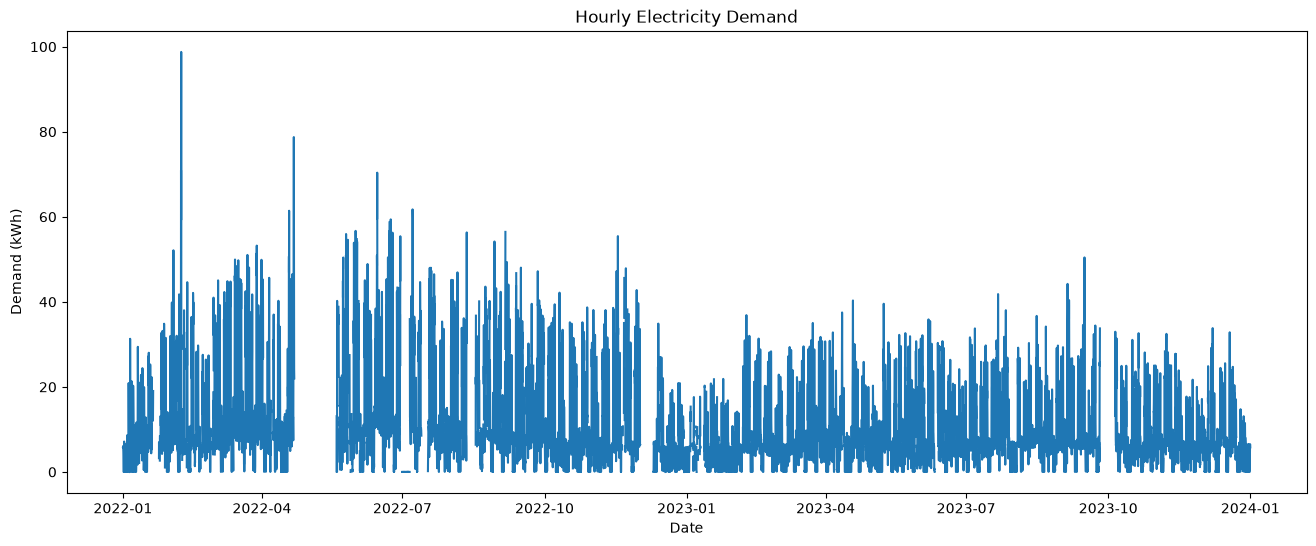

In [9]:
#plot the time series
#Plot the complete time series
plt.figure(figsize=(16, 6))

plt.plot(
    df.index,
    df["demand_kWh"]
)

plt.title("Hourly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Demand (kWh)")

plt.show()

In [10]:
#percentage of missing values
missing_percentage = df.isnull().mean() * 100

print(missing_percentage)

demand_kWh    16.233803
dtype: float64


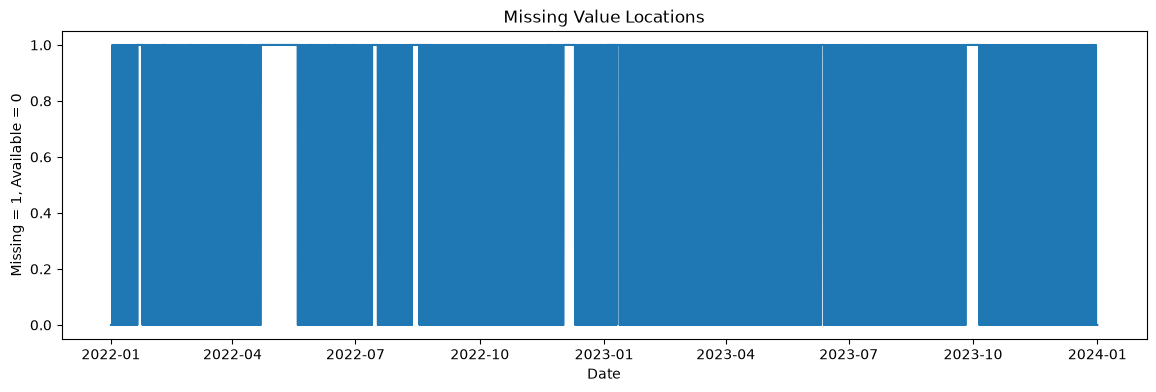

In [11]:
#Plot the missing values
plt.figure(figsize=(14, 4))

plt.plot(
    df.index,
    df["demand_kWh"].isnull().astype(int)
)

plt.title("Missing Value Locations")
plt.xlabel("Date")
plt.ylabel("Missing = 1, Available = 0")

plt.show()

#### Fill Missing Values
#### For time-series data, interpolation is generally preferable to simply replacing everything with the mean.
#### First, interpolate using time:

In [12]:
df["demand_kWh"] = df["demand_kWh"].interpolate(
    method="time"
)

In [13]:
df["demand_kWh"] = df["demand_kWh"].bfill()
df["demand_kWh"] = df["demand_kWh"].ffill()

In [14]:
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
demand_kWh    0
dtype: int64


#### basic statistical data exploration

In [15]:
print(df["demand_kWh"].describe())

count    17519.000000
mean        10.679483
std          9.346191
min          0.000000
25%          5.690000
50%          7.400000
75%         13.265000
max         98.760000
Name: demand_kWh, dtype: float64


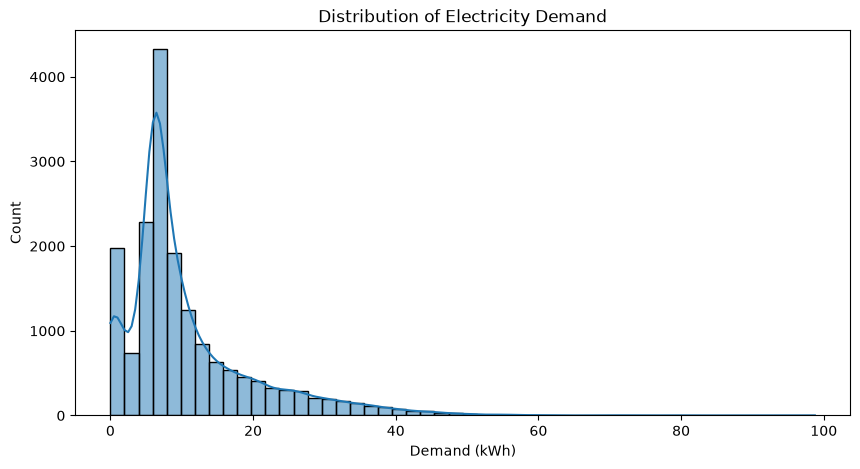

In [16]:
#Plot a histogram of the demand_kWh column
plt.figure(figsize=(10, 5))

sns.histplot(
    df["demand_kWh"],
    bins=50,
    kde=True
)

plt.title("Distribution of Electricity Demand")
plt.xlabel("Demand (kWh)")

plt.show()

##### The electricity-demand distribution is positively skewed, with most observations concentrated between approximately 2 and 15 kWh and a mode around 6–8 kWh. The long right tail indicates that high-demand events occur less frequently but may be important for forecasting and system planning. Because the distribution is not symmetric or normally distributed, the mean may be influenced by extreme high-demand observations; therefore, the median, quartiles, and upper-percentile values should also be examined.
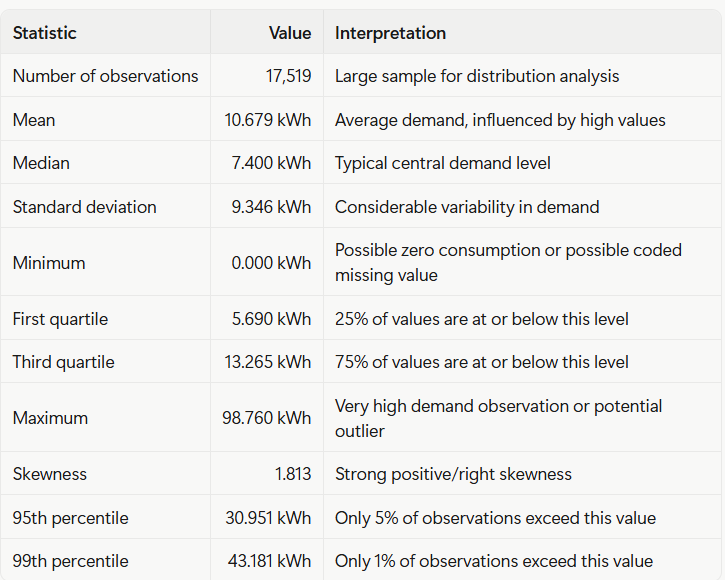

In [17]:
print(df["demand_kWh"].describe())
print("Skewness:", df["demand_kWh"].skew())
print("Median:", df["demand_kWh"].median())
print("95th percentile:", df["demand_kWh"].quantile(0.95))
print("99th percentile:", df["demand_kWh"].quantile(0.99))


count    17519.000000
mean        10.679483
std          9.346191
min          0.000000
25%          5.690000
50%          7.400000
75%         13.265000
max         98.760000
Name: demand_kWh, dtype: float64
Skewness: 1.813087867254362
Median: 7.4
95th percentile: 30.950999999999986
99th percentile: 43.18099999999998


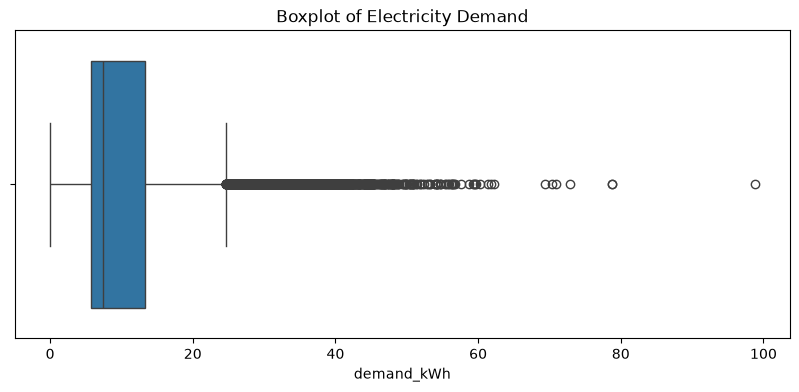

In [18]:
#box plot
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["demand_kWh"])

plt.title("Boxplot of Electricity Demand")

plt.show()

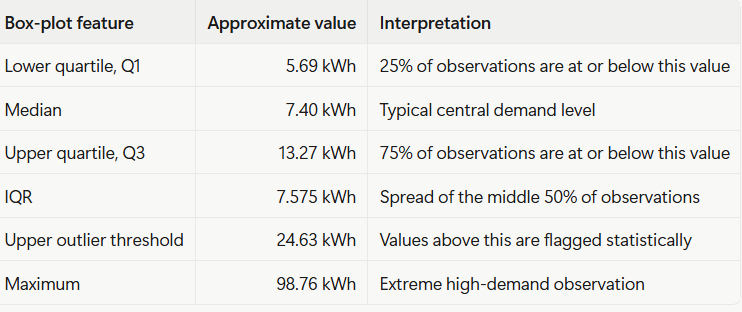

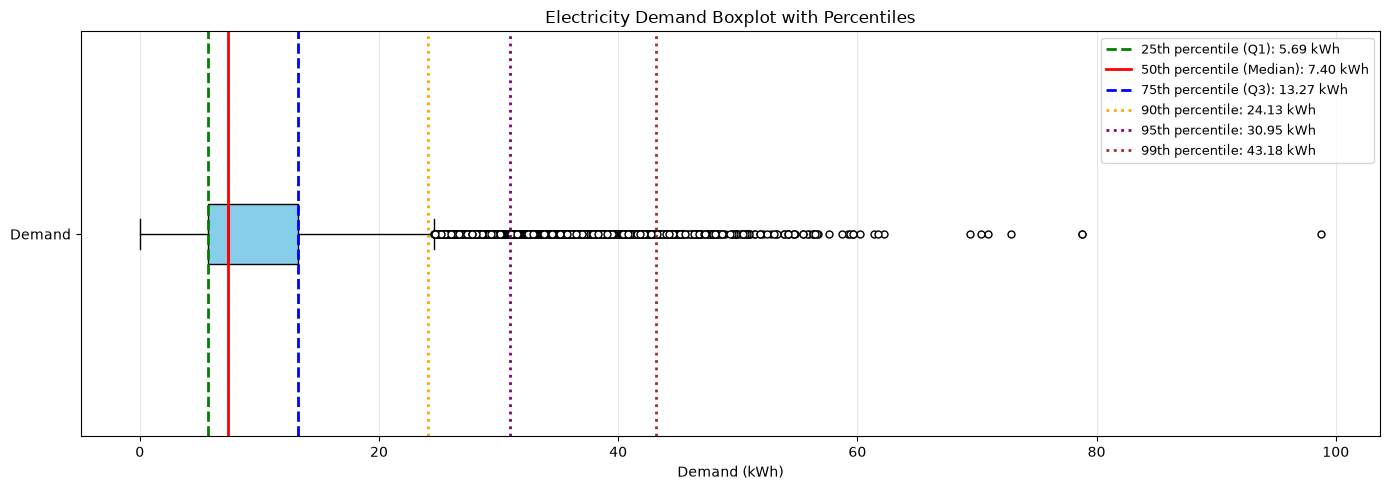

In [19]:
series = df["demand_kWh"].dropna()

# Calculate percentiles
percentiles = series.quantile([
    0.25, 0.50, 0.75, 0.90, 0.95, 0.99
])

q1 = percentiles[0.25]
median = percentiles[0.50]
q3 = percentiles[0.75]
p90 = percentiles[0.90]
p95 = percentiles[0.95]
p99 = percentiles[0.99]

fig, ax = plt.subplots(figsize=(14, 5))

# Draw the boxplot horizontally
ax.boxplot(
    series,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="black"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=5
    )
)

# Draw and label the quartiles
ax.axvline(q1, color="green", linestyle="--", linewidth=2,
           label=f"25th percentile (Q1): {q1:.2f} kWh")

ax.axvline(median, color="red", linestyle="-", linewidth=2,
           label=f"50th percentile (Median): {median:.2f} kWh")

ax.axvline(q3, color="blue", linestyle="--", linewidth=2,
           label=f"75th percentile (Q3): {q3:.2f} kWh")

# Draw additional percentiles
ax.axvline(p90, color="orange", linestyle=":", linewidth=2,
           label=f"90th percentile: {p90:.2f} kWh")

ax.axvline(p95, color="purple", linestyle=":", linewidth=2,
           label=f"95th percentile: {p95:.2f} kWh")

ax.axvline(p99, color="brown", linestyle=":", linewidth=2,
           label=f"99th percentile: {p99:.2f} kWh")

ax.set_title("Electricity Demand Boxplot with Percentiles")
ax.set_xlabel("Demand (kWh)")
ax.set_yticks([1])
ax.set_yticklabels(["Demand"])
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


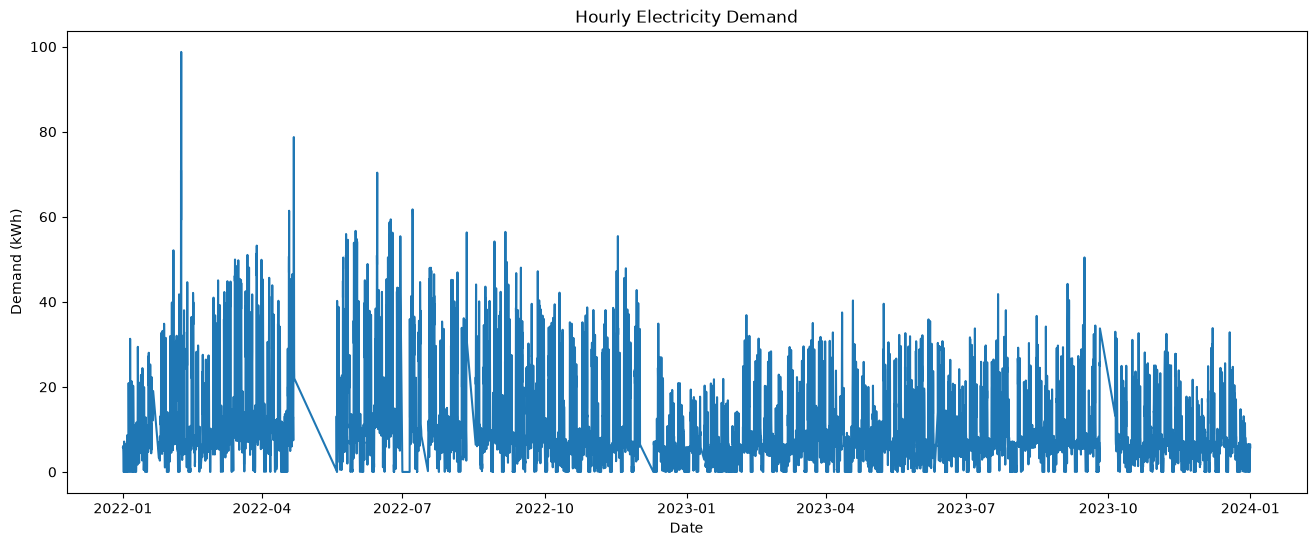

In [20]:
#Plot the complete time series
plt.figure(figsize=(16, 6))

plt.plot(
    df.index,
    df["demand_kWh"]
)

plt.title("Hourly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Demand (kWh)")

plt.show()

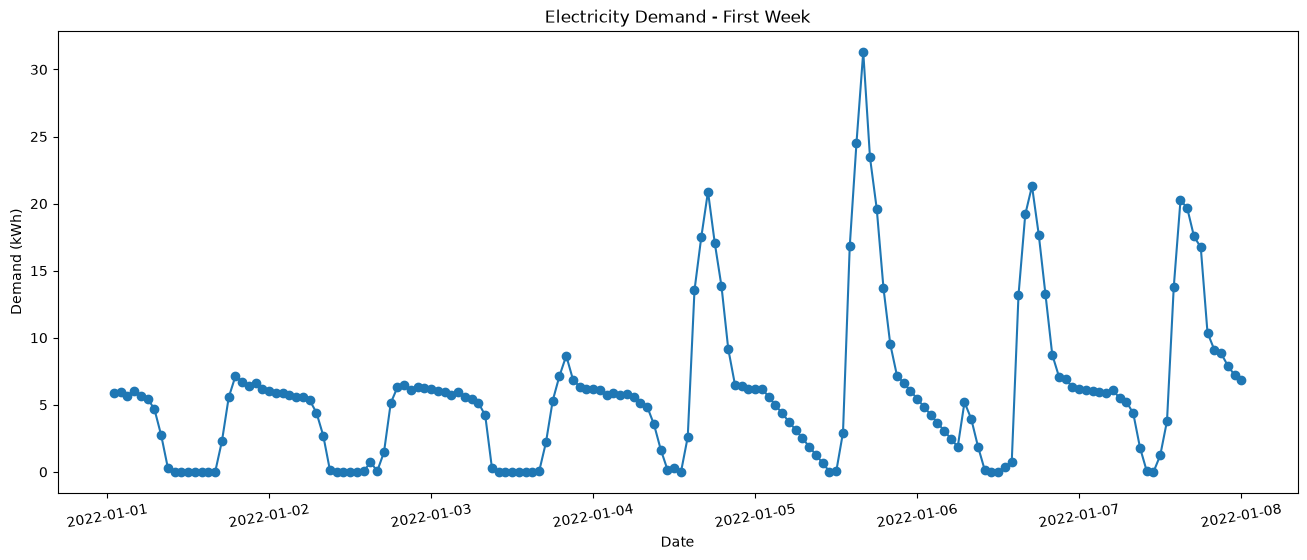

In [21]:
#weekly time series
one_week = df.iloc[:24 * 7]

plt.figure(figsize=(16, 6))

plt.plot(
    one_week.index,
    one_week["demand_kWh"],
    marker="o"
)

plt.title("Electricity Demand - First Week")
plt.xlabel("Date")
plt.ylabel("Demand (kWh)")

plt.xticks(rotation=10)

plt.show()

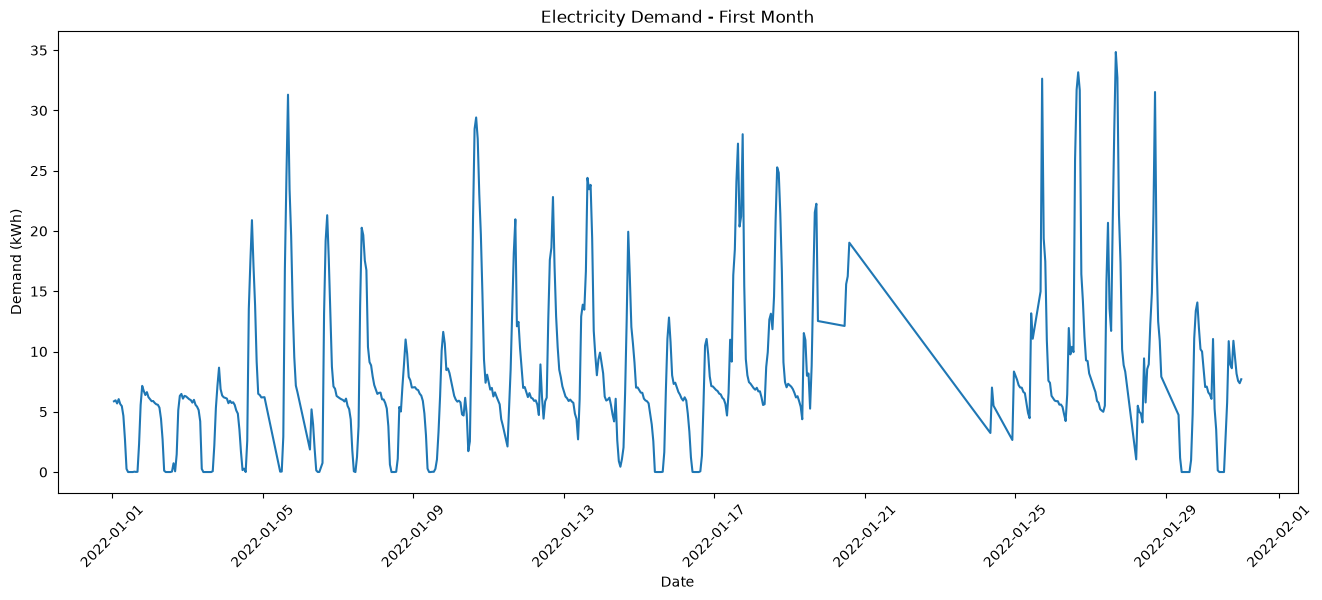

In [22]:
#plot for one month
one_month = df.iloc[:24 * 30]

plt.figure(figsize=(16, 6))

plt.plot(
    one_month.index,
    one_month["demand_kWh"]
)

plt.title("Electricity Demand - First Month")
plt.xlabel("Date")
plt.ylabel("Demand (kWh)")

plt.xticks(rotation=45)

plt.show()

#### The first month exhibits strong daily seasonality but no obvious consistent long-term trend. Demand repeatedly falls to very low levels and rises to daily peaks, while the magnitude of those peaks varies over time. The isolated extreme peaks may be genuine high-demand events or possible anomalies

#### Rolling Mean and Rolling Standard Deviation

This helps identify the trend and changing variability.

In [23]:
#24 hour rolling window
df["rolling_mean_24"] = df["demand_kWh"].rolling(
    window=24
).mean()

df["rolling_std_24"] = df["demand_kWh"].rolling(
    window=24
).std()

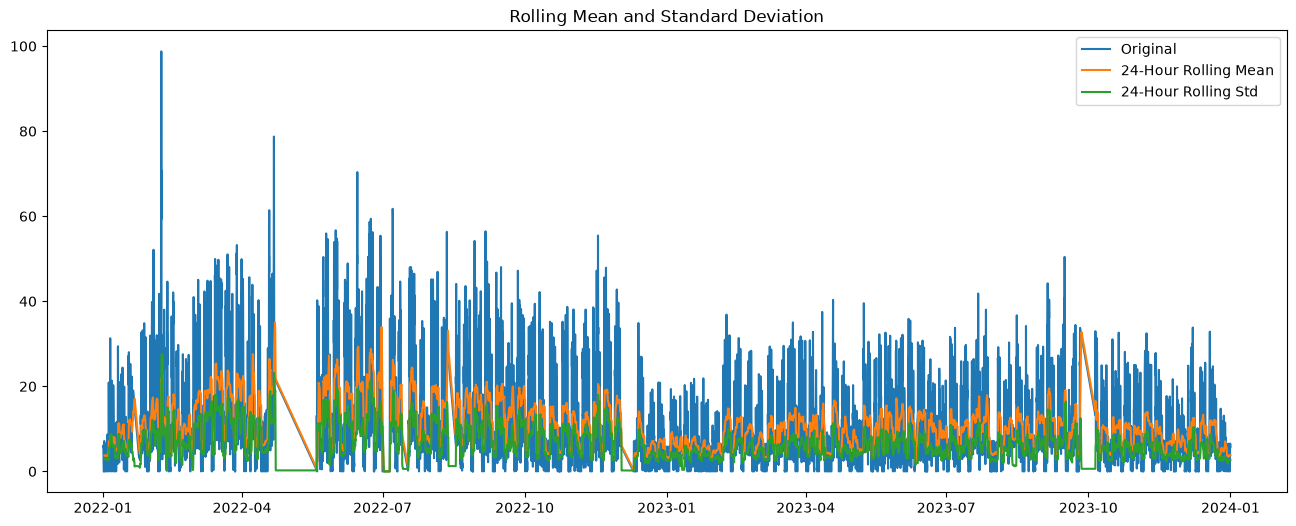

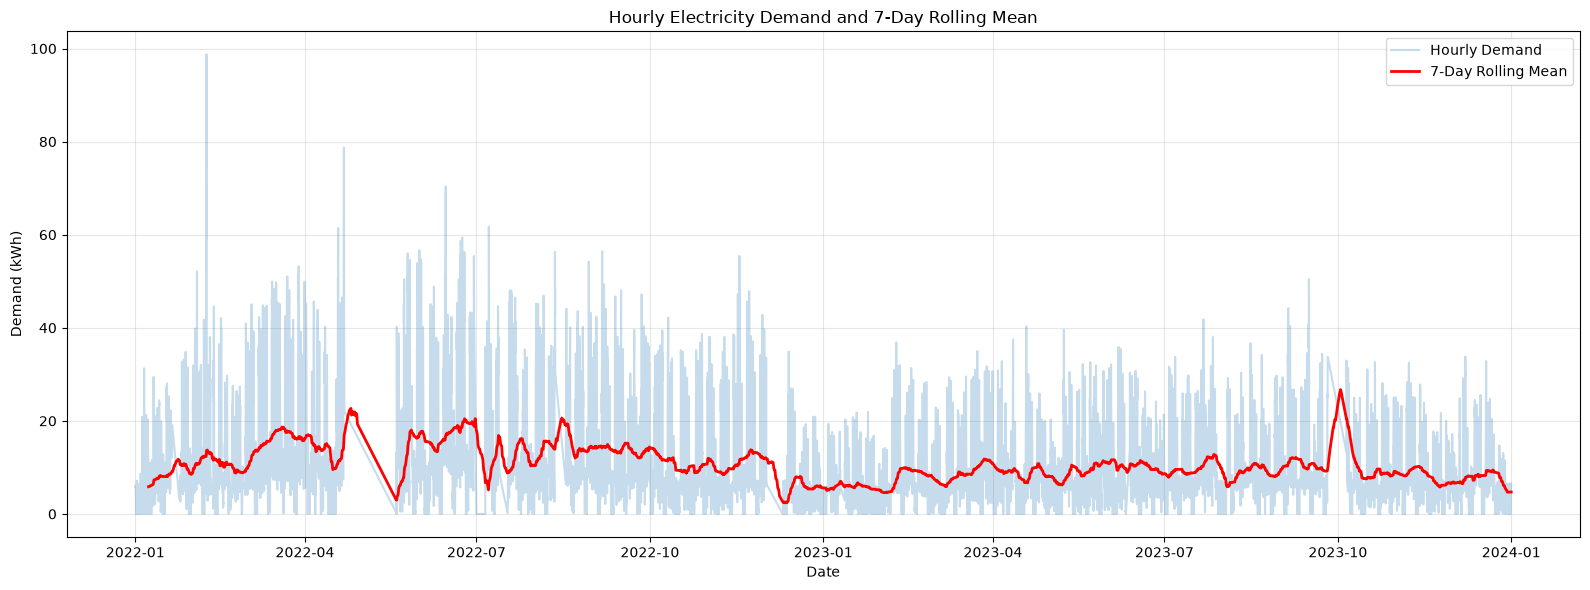

In [24]:
plt.figure(figsize=(16, 6))

plt.plot(
    df["demand_kWh"],
    label="Original"
)

plt.plot(
    df["rolling_mean_24"],
    label="24-Hour Rolling Mean"
)

plt.plot(
    df["rolling_std_24"],
    label="24-Hour Rolling Std"
)

plt.title("Rolling Mean and Standard Deviation")
plt.legend()
df["rolling_mean_7d"] = (
    df["demand_kWh"]
    .rolling(window=24 * 7)
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    df["demand_kWh"],
    alpha=0.25,
    label="Hourly Demand"
)

plt.plot(
    df["rolling_mean_7d"],
    color="red",
    linewidth=2,
    label="7-Day Rolling Mean"
)

plt.title("Hourly Electricity Demand and 7-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Demand (kWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.show()

### Stationarity Test — ADF Test 
#### What the ADF test measures
The Augmented Dickey–Fuller (ADF) test is a statistical test used to assess whether a time series is stationary or contains a unit root.
A stationary series has relatively stable statistical properties over time, such as a stable mean, variance, and autocorrelation structure. A non-stationary series may contain a persistent trend, changing level, or unit-root behavior, making many forecasting models less reliable unless the series is transformed.
The ADF test is based on these hypotheses:
| Hypothesis                     | Meaning                                                 |
| ------------------------------ | ------------------------------------------------------- |
| **Null hypothesis, H₀**        | The series has a unit root and is non-stationary.       |
| **Alternative hypothesis, H₁** | The series does not have a unit root and is stationary. |

In [25]:
def adf_test(series):

    result = adfuller(series.dropna())

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Number of Lags Used:", result[2])
    print("Number of Observations:", result[3])

    print("\nCritical Values:")

    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] <= 0.05:
        print("\nConclusion: The series is likely STATIONARY.")
    else:
        print("\nConclusion: The series is likely NON-STATIONARY.")

In [26]:
adf_test(df["demand_kWh"])

ADF Statistic: -13.605168702110001
p-value: 1.9195350958334034e-25
Number of Lags Used: 44
Number of Observations: 17474

Critical Values:
1%: -3.4307242852745428
5%: -2.8617054196196627
10%: -2.566858048572343

Conclusion: The series is likely STATIONARY.


| Output                     |      Your result | What it means for your original series                                                                                                                                        |
| -------------------------- | ---------------: | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ADF Statistic**          |       `-13.6052` | This is the calculated ADF test statistic. More negative values provide stronger evidence against a unit root.                                                                |
| **p-value**                | `1.9195 × 10⁻²⁵` | This is effectively zero and is far below `0.05`. Therefore, reject the null hypothesis that the series has a unit root.                                                      |
| **Number of Lags Used**    |             `44` | The test included 44 lagged differences to account for autocorrelation in the data. This is a model adjustment, not evidence that 44 differences were applied to your series. |
| **Number of Observations** |         `17,474` | The test used 17,474 observations after accounting for missing values and the lag structure.                                                                                  |
| **1% Critical Value**      |        `-3.4307` | Your statistic, `-13.6052`, is more negative, so the null is rejected at the 1% level.                                                                                        |
| **5% Critical Value**      |        `-2.8617` | Your statistic is more negative, so the null is rejected at the 5% level.                                                                                                     |
| **10% Critical Value**     |        `-2.5669` | Your statistic is more negative, so the null is rejected at the 10% level.                                                                                                    |

p-value = 1.9195e-25
0.000000000000000000000019195 < 0.05


<Figure size 1400x600 with 0 Axes>

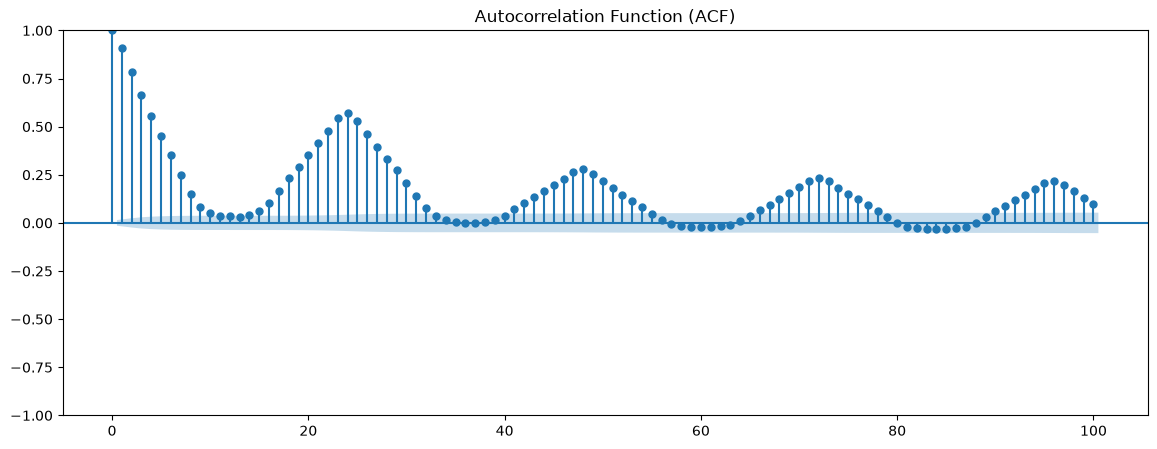

In [ ]:
# Plot ACF for MA(q)
plt.figure(figsize=(14, 6))

plot_acf(
    series,
    lags=100,
    alpha=0.05
)

plt.title("Autocorrelation Function (ACF)")

plt.show()

<Figure size 1600x600 with 0 Axes>

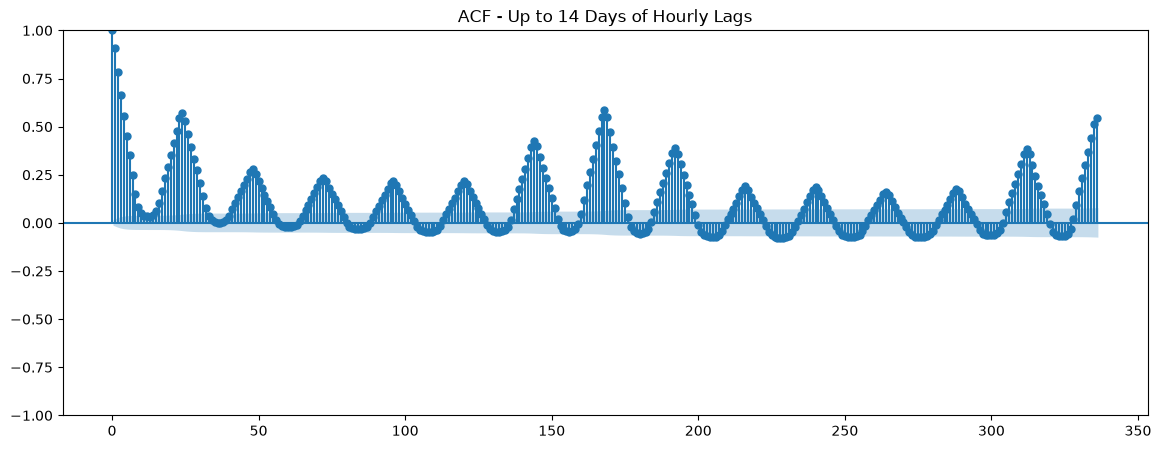

In [29]:
## try longer lags
plt.figure(figsize=(16, 6))

plot_acf(
    series,
    lags=24 * 14,
    alpha=0.05
)

plt.title("ACF - Up to 14 Days of Hourly Lags")

plt.show()

<Figure size 1400x600 with 0 Axes>

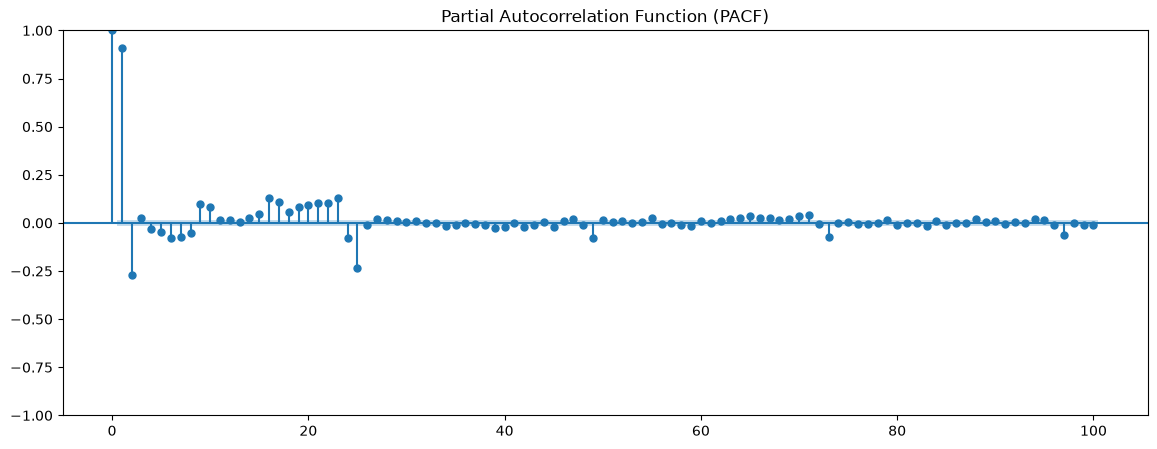

In [30]:
#plot PACF for AR(p)
plt.figure(figsize=(14, 6))

plot_pacf(
    series,
    lags=100,
    alpha=0.05,
    method="ywm"
)

plt.title("Partial Autocorrelation Function (PACF)")

plt.show()

<Figure size 1600x600 with 0 Axes>

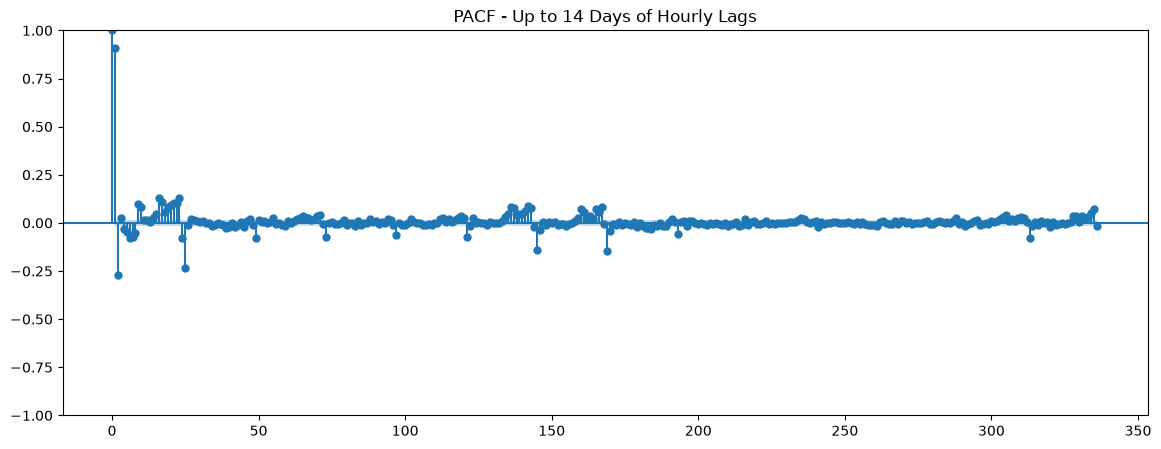

In [33]:
# for longer view
plt.figure(figsize=(16, 6))

plot_pacf(
    series,
    lags=24 * 14,
    alpha=0.05,
    method="ywm"
)

plt.title("PACF - Up to 14 Days of Hourly Lags")

plt.show()

| Model     | ACF                 | PACF                |
| --------- | ------------------- | ------------------- |
| AR(p)     | Gradually tails off | Cuts off after p    |
| MA(q)     | Cuts off after q    | Gradually tails off |
| ARMA(p,q) | Tails off           | Tails off           |


## Time series decomposition
For hourly data, the first test is daily seasonality, which is 24 hours

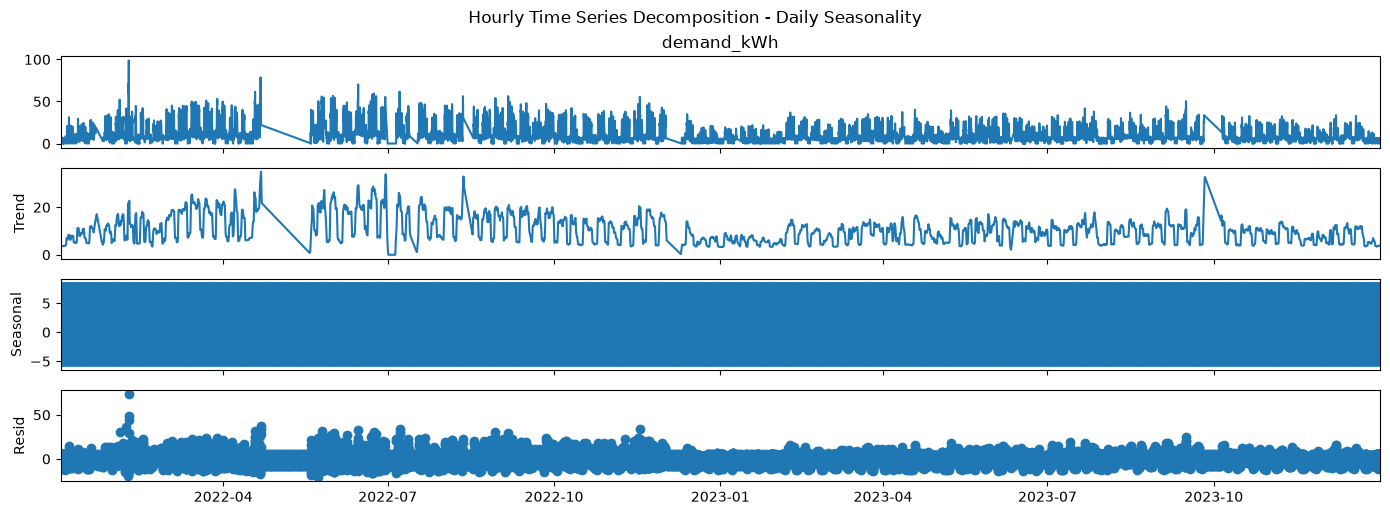

In [34]:
decomposition_hourly = seasonal_decompose(
    df["demand_kWh"],
    model="additive",
    period=24
)

decomposition_hourly.plot()

plt.suptitle(
    "Hourly Time Series Decomposition - Daily Seasonality",
    y=1.02
)

plt.show()

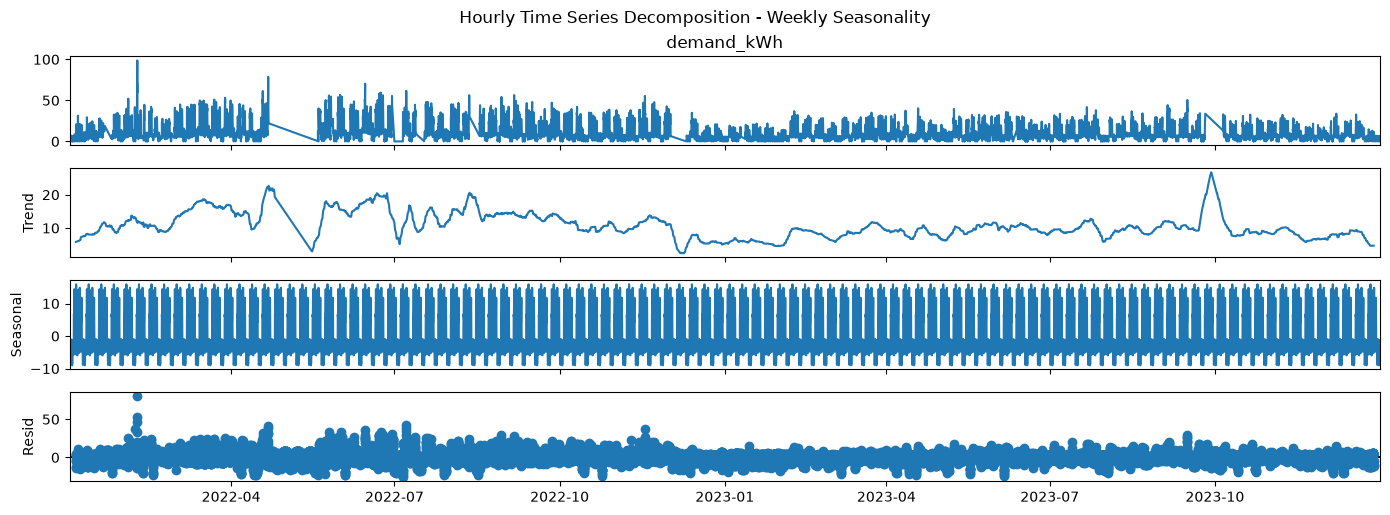

In [35]:
# weekly seasonality
decomposition_weekly = seasonal_decompose(
    df["demand_kWh"],
    model="additive",
    period=168
)

decomposition_weekly.plot()

plt.suptitle(
    "Hourly Time Series Decomposition - Weekly Seasonality",
    y=1.02
)

plt.show()

### Data resampling

In [38]:
#daily resampling
daily_df = df["demand_kWh"].resample("D").sum()
daily_df.head()

datetime
2022-01-01     83.35000
2022-01-02     86.22500
2022-01-03     93.37500
2022-01-04    170.25000
2022-01-05    202.28375
Freq: D, Name: demand_kWh, dtype: float64

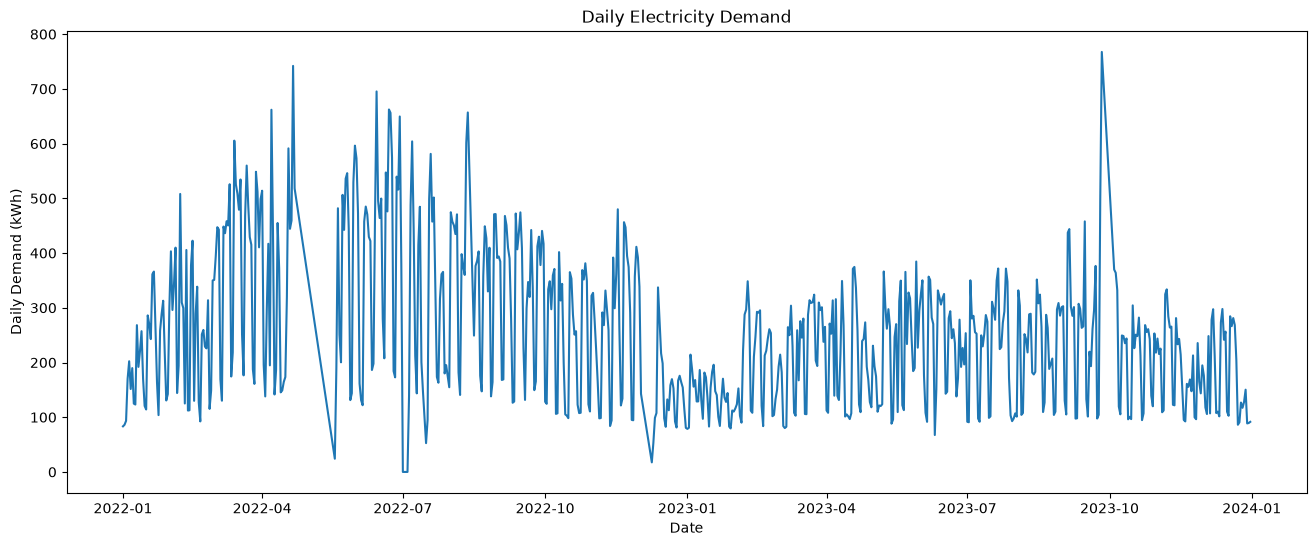

In [39]:
plt.figure(figsize=(16, 6))

plt.plot(daily_df)

plt.title("Daily Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Daily Demand (kWh)")

plt.show()

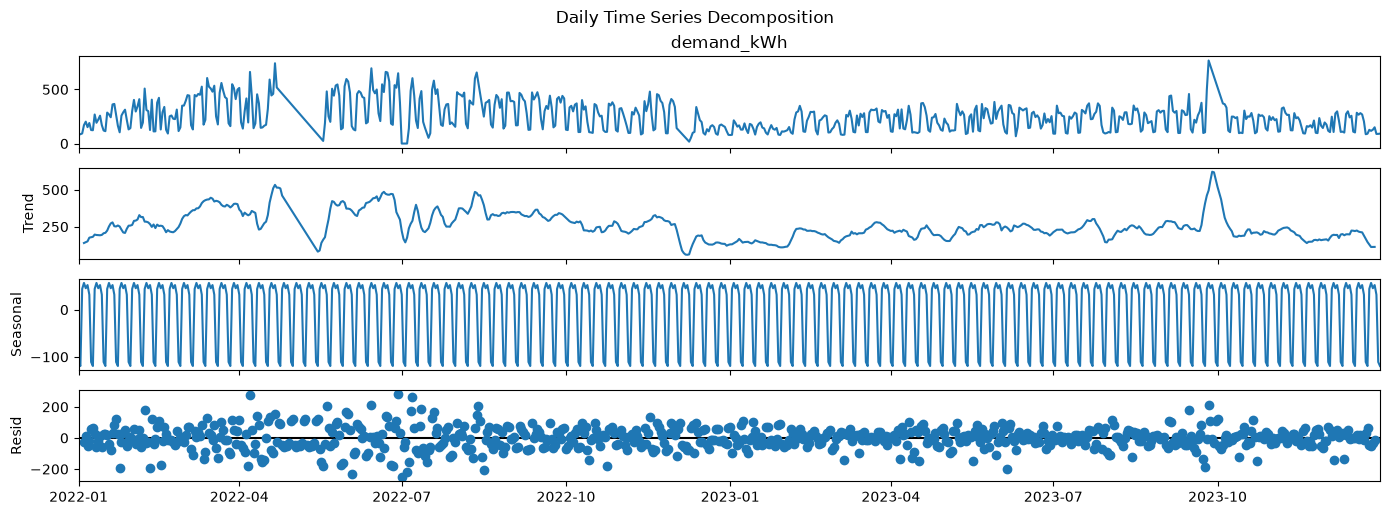

In [40]:
daily_decomposition = seasonal_decompose(
    daily_df,
    model="additive",
    period=7
)

daily_decomposition.plot()

plt.suptitle(
    "Daily Time Series Decomposition",
    y=1.02
)

plt.show()

In [41]:
# resample data to weekly frequency
weekly_df = df["demand_kWh"].resample("W").sum()

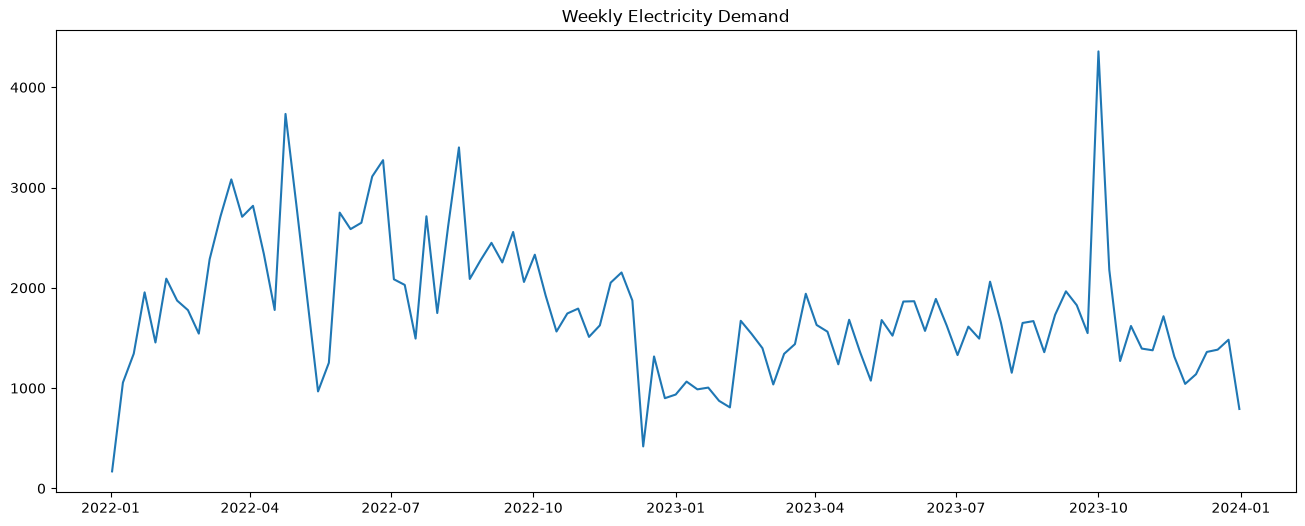

In [42]:
plt.figure(figsize=(16, 6))

plt.plot(weekly_df)

plt.title("Weekly Electricity Demand")

plt.show()

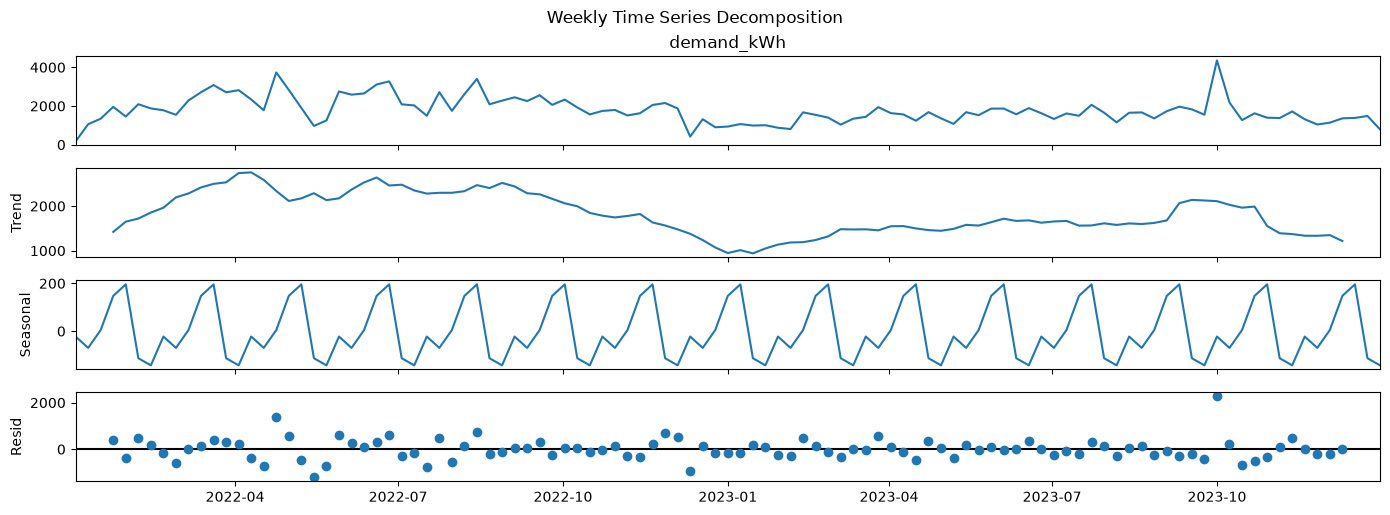

In [43]:
#weekly decomposition
weekly_decomposition = seasonal_decompose(
    weekly_df,
    model="additive",
    period=7
)

weekly_decomposition.plot()

plt.suptitle(
    "Weekly Time Series Decomposition",
    y=1.02
)

plt.show()

In [47]:
#monthly resampling
monthly_df = df["demand_kWh"].resample("ME").sum()


datetime
2022-01-31     6279.675000
2022-02-28     7334.725000
2022-03-31    12406.655000
2022-04-30    11182.009384
2022-05-31     8340.425616
2022-06-30    12578.495000
2022-07-31     7985.320000
2022-08-31    11709.075000
2022-09-30    10062.350000
2022-10-31     7599.655000
2022-11-30     8179.910000
2022-12-31     4204.675000
2023-01-31     4232.375000
2023-02-28     5478.695000
2023-03-31     6884.090000
2023-04-30     6064.275000
2023-05-31     7045.940000
2023-06-30     7191.105000
2023-07-31     7101.920000
2023-08-31     6924.390000
2023-09-30     9717.766387
2023-10-31     7453.828613
2023-11-30     5718.120000
2023-12-31     5418.380000
Freq: ME, Name: demand_kWh, dtype: float64


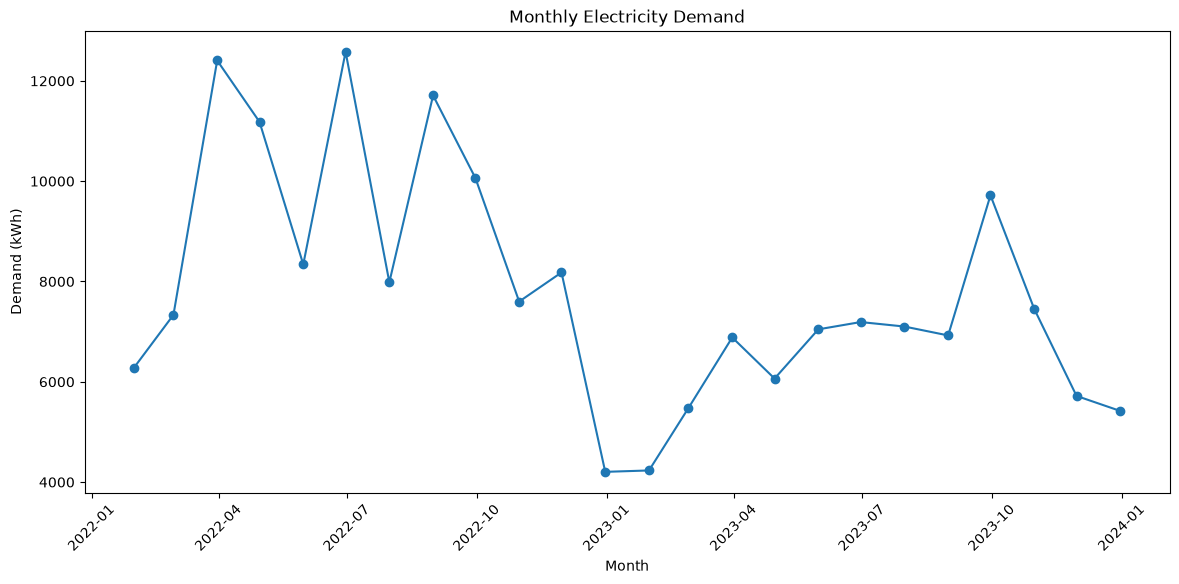

In [48]:
print(monthly_df)
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_df,
    marker="o"
)

plt.title("Monthly Electricity Demand")
plt.xlabel("Month")
plt.ylabel("Demand (kWh)")

plt.xticks(rotation=45)

plt.show()

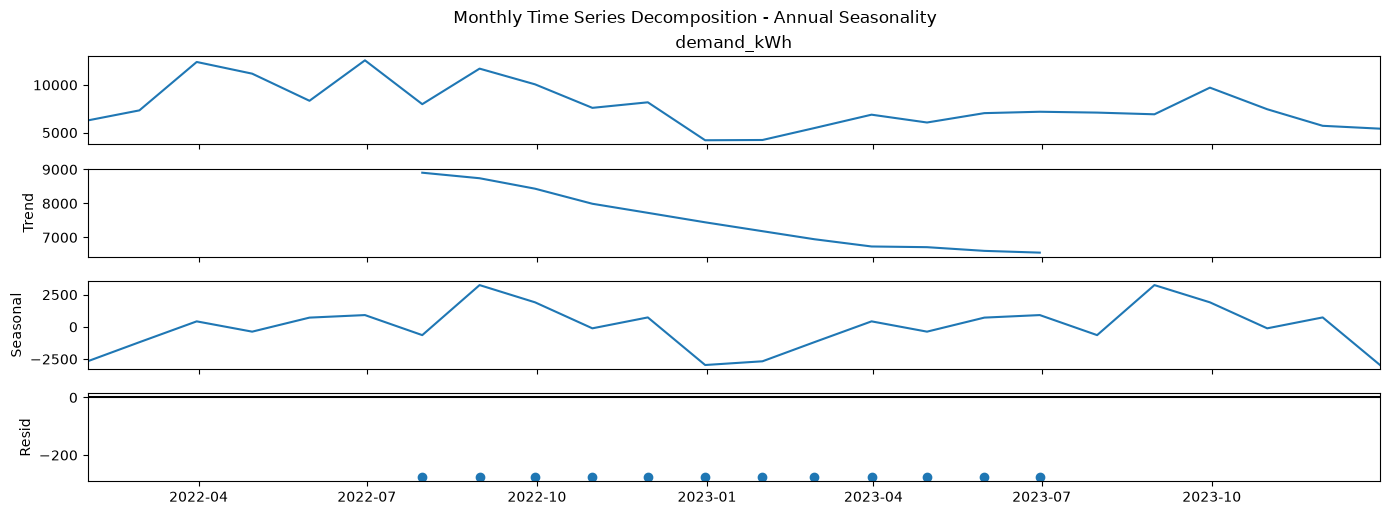

In [49]:
#monthly decomposition
monthly_decomposition = seasonal_decompose(
    monthly_df,
    model="additive",
    period=12
)

monthly_decomposition.plot()

plt.suptitle(
    "Monthly Time Series Decomposition - Annual Seasonality",
    y=1.02
)

plt.show()

In [50]:

def plot_resampled_series(df, column):

    frequencies = {
        "Hourly": "h",
        "Daily": "D",
        "Weekly": "W",
        "Monthly": "ME"
    }

    for name, freq in frequencies.items():

        resampled = df[column].resample(freq).sum()

        plt.figure(figsize=(16, 5))

        plt.plot(resampled)

        plt.title(f"{name} Electricity Demand")
        plt.xlabel("Time")
        plt.ylabel("Demand (kWh)")

        plt.show()

        print(f"{name} observations: {len(resampled)}")

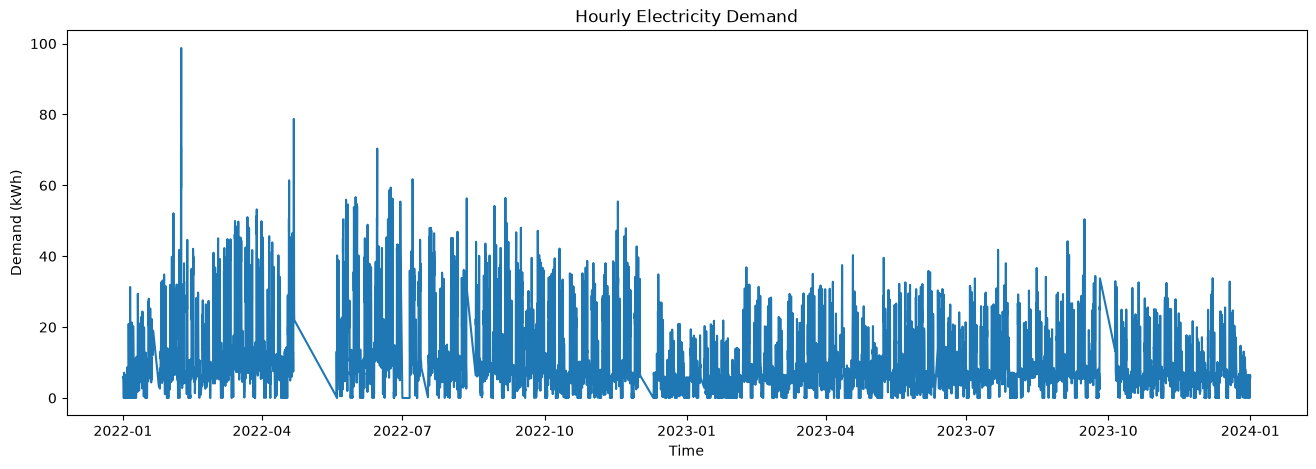

Hourly observations: 17519


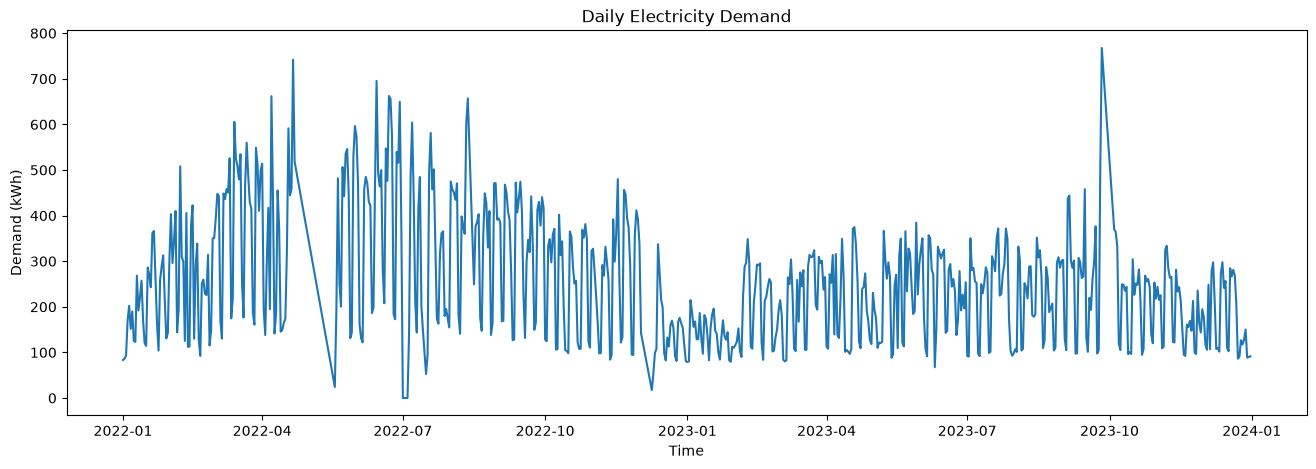

Daily observations: 730


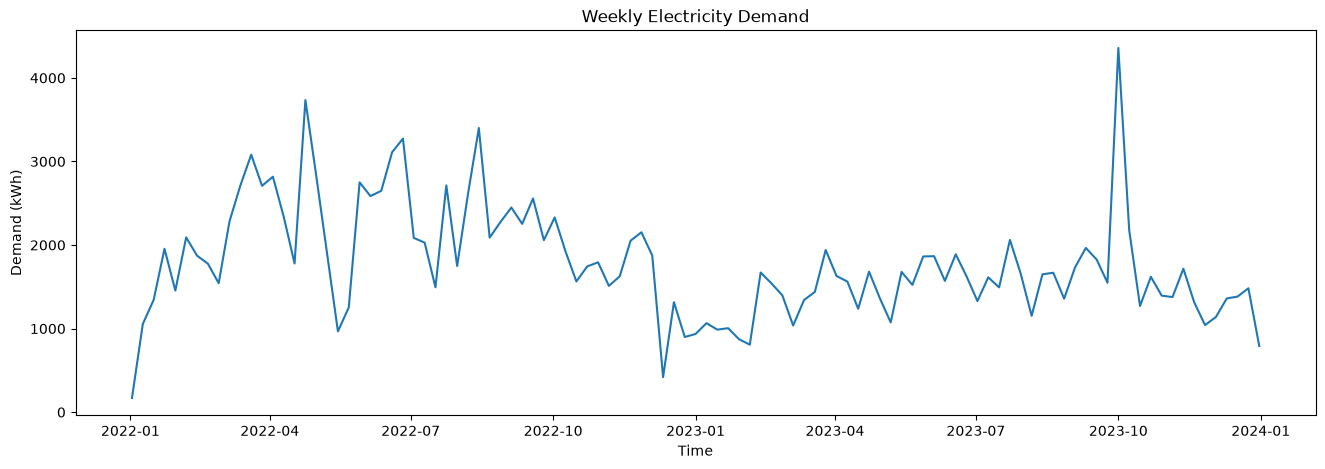

Weekly observations: 105


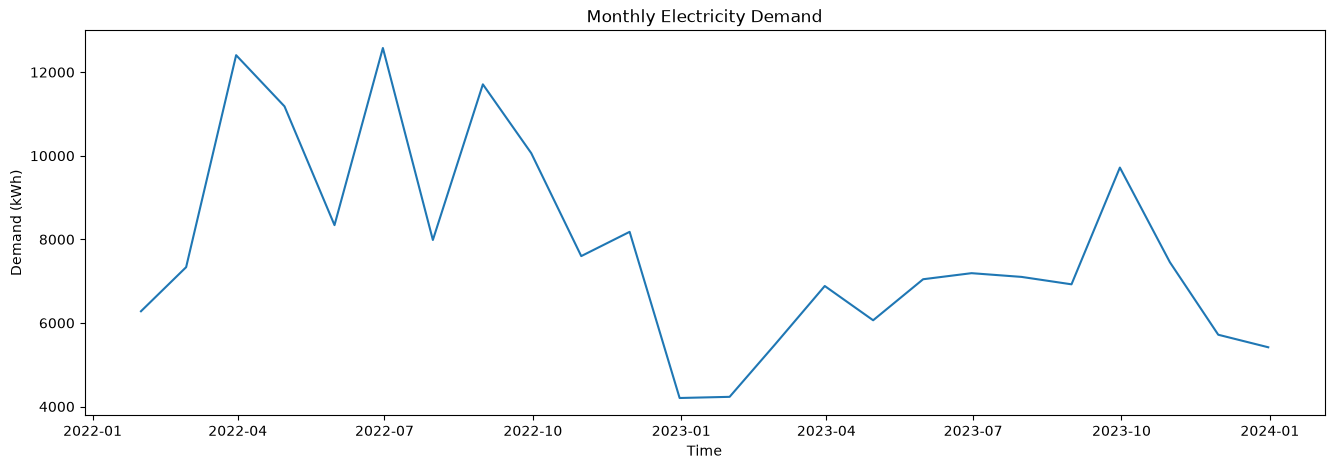

Monthly observations: 24


In [51]:
plot_resampled_series(df, "demand_kWh")

In [52]:
#automatic decomposition
def perform_decomposition(series, period, title):

    result = seasonal_decompose(
        series.dropna(),
        model="additive",
        period=period
    )

    fig = result.plot()

    fig.set_size_inches(14, 10)

    plt.suptitle(title, y=1.02)

    plt.show()

    return result

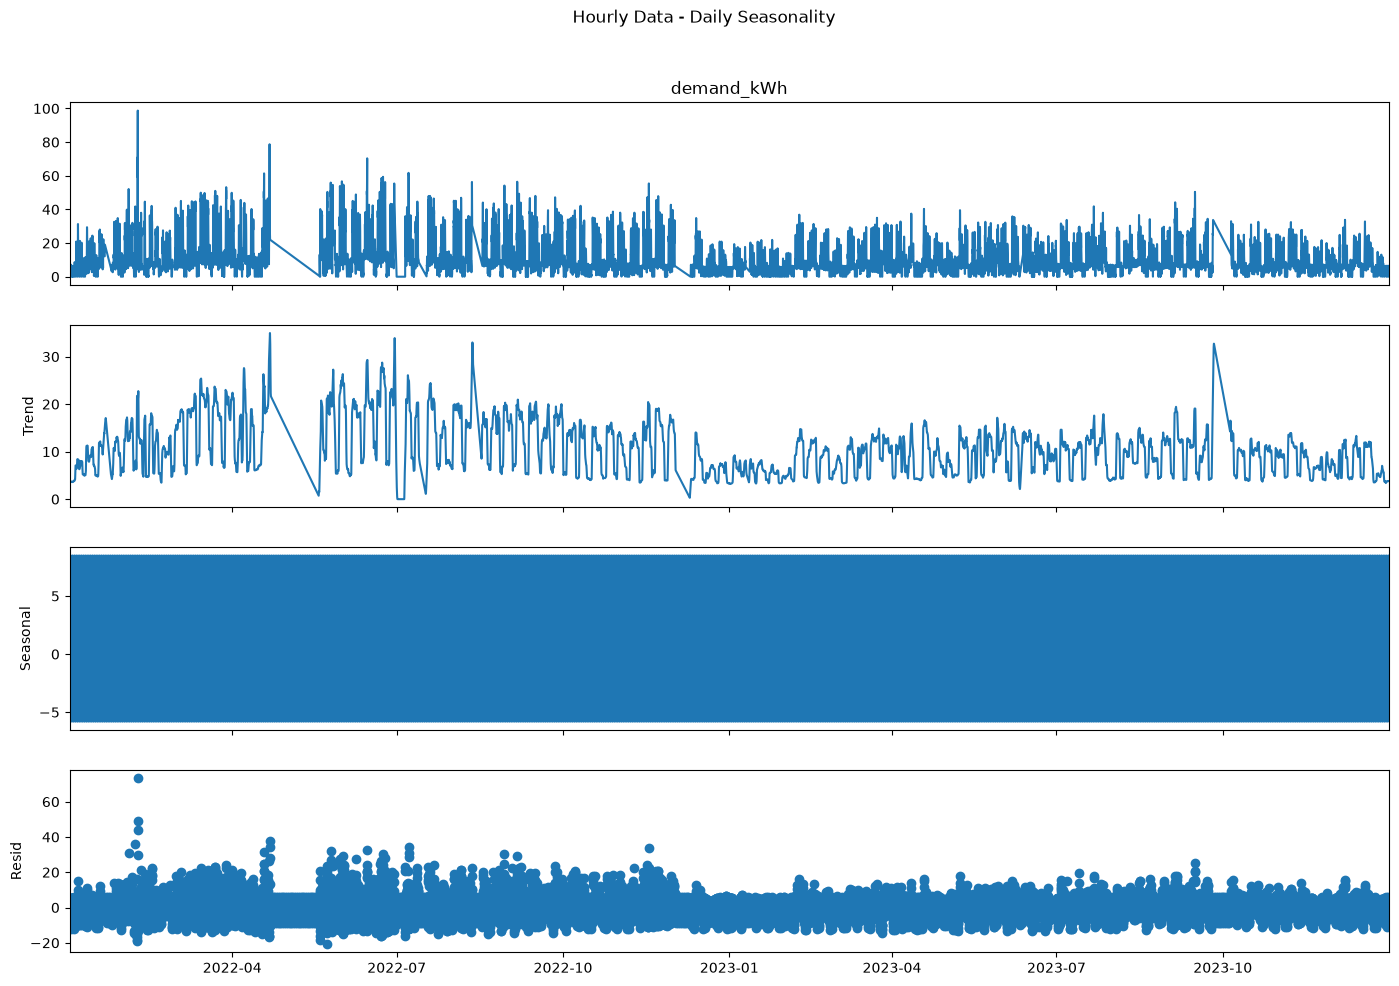

In [53]:
#hourly daily pattern
hourly_daily_decomp = perform_decomposition(
    df["demand_kWh"],
    period=24,
    title="Hourly Data - Daily Seasonality"
)

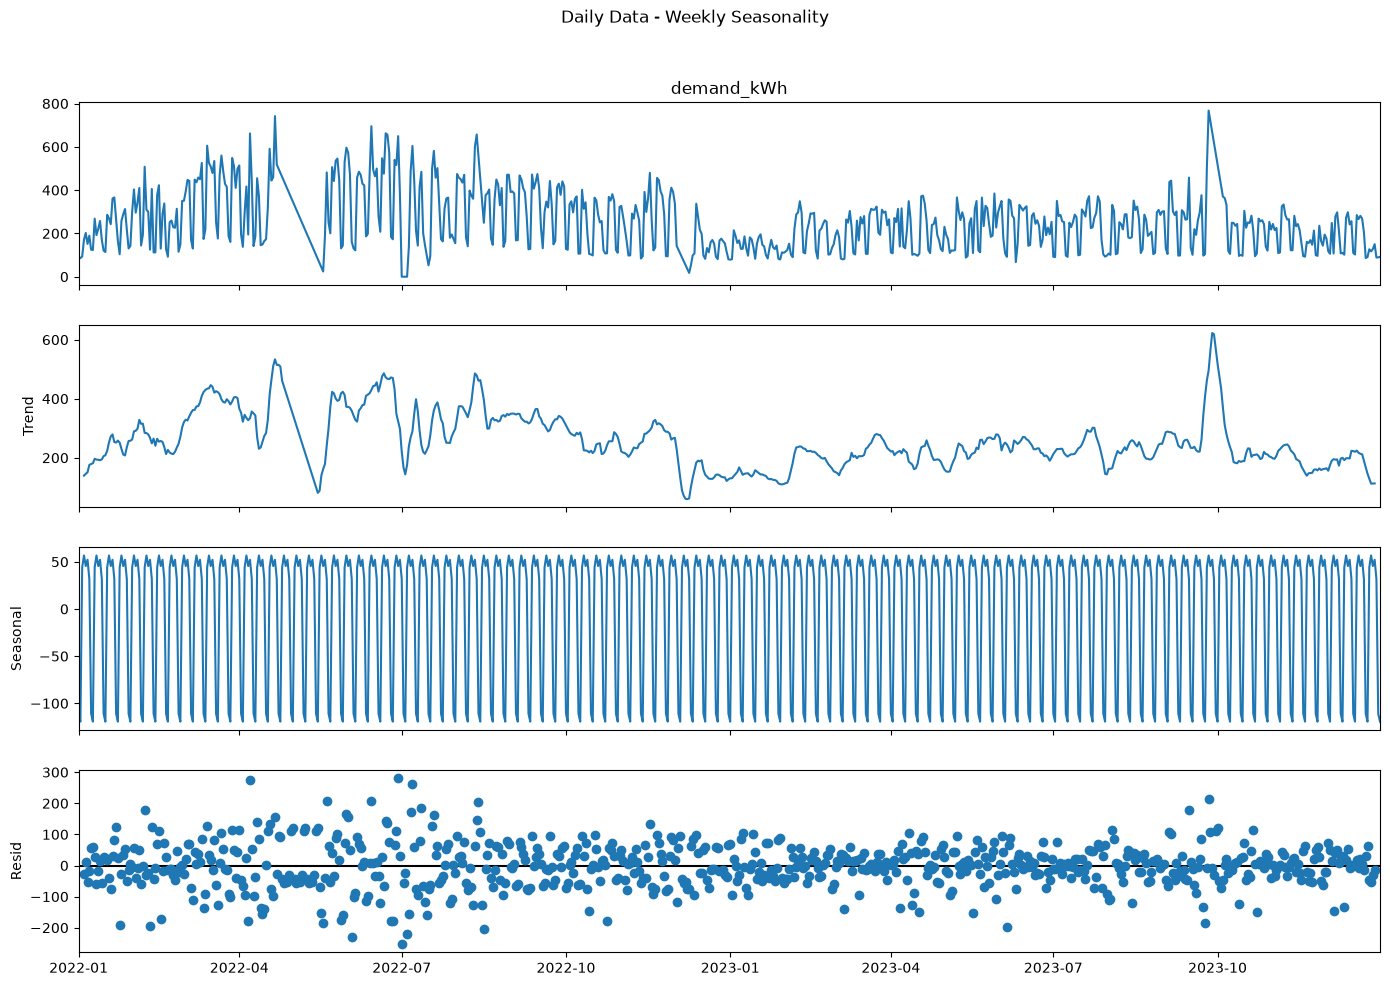

In [55]:
#daily weekly pattern
daily_weekly_decomp = perform_decomposition(
    daily_df,
    period=7,
    title="Daily Data - Weekly Seasonality"
)

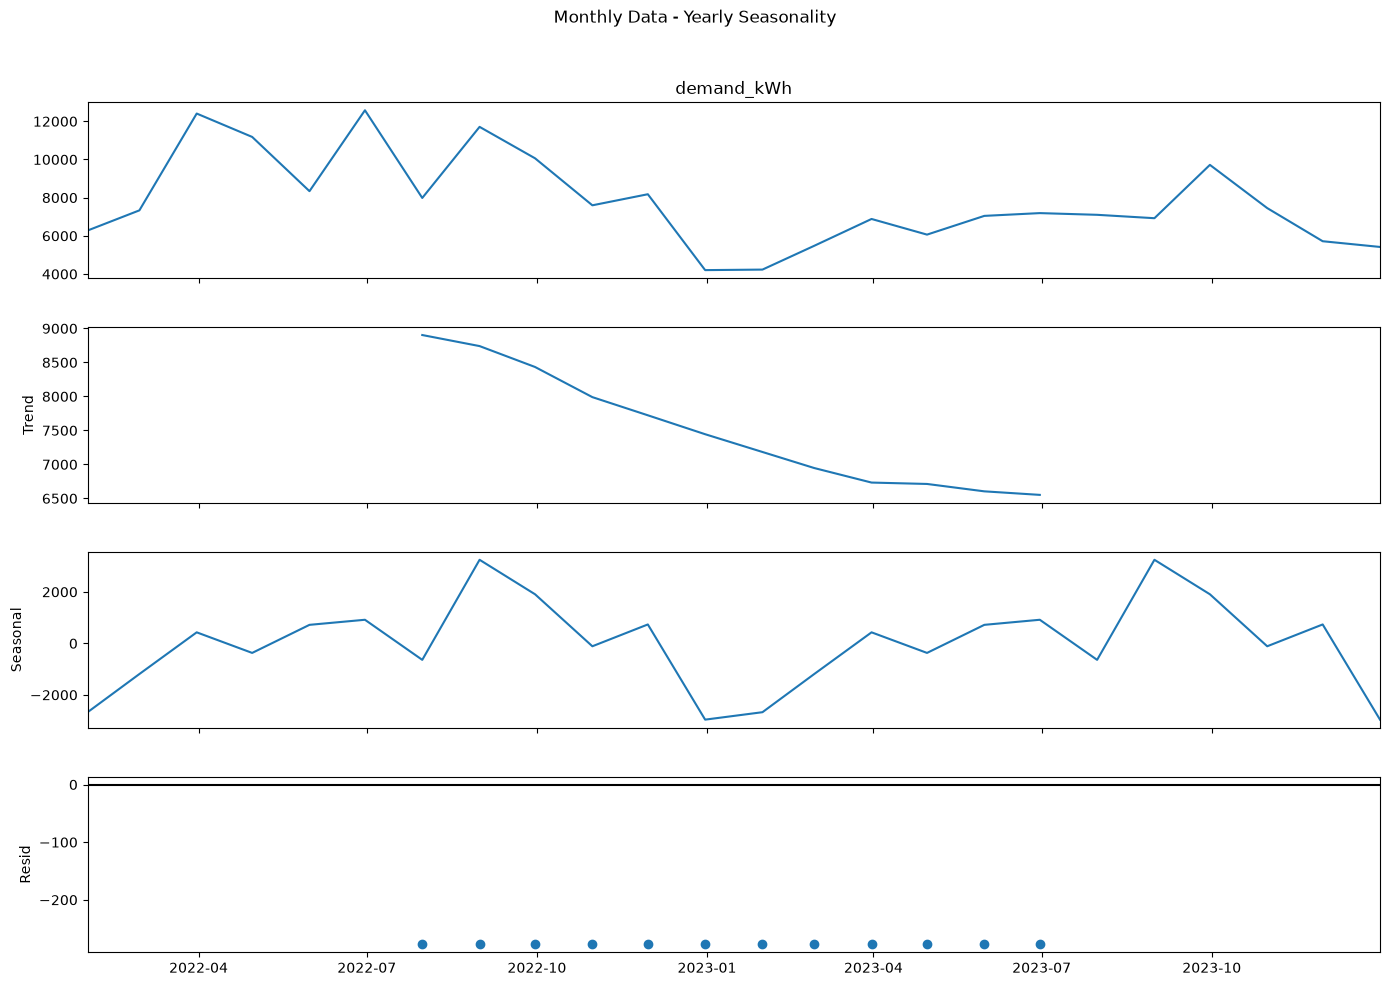

In [56]:
#monthly weekly 
if len(monthly_df) >= 24:
    monthly_yearly_decomp = perform_decomposition(
        monthly_df,
        period=12,
        title="Monthly Data - Yearly Seasonality"
    )

# Trend Analysis

In [57]:
df["trend_30d"] = df["demand_kWh"].rolling(
    window=24 * 30,
    center=True
).mean()

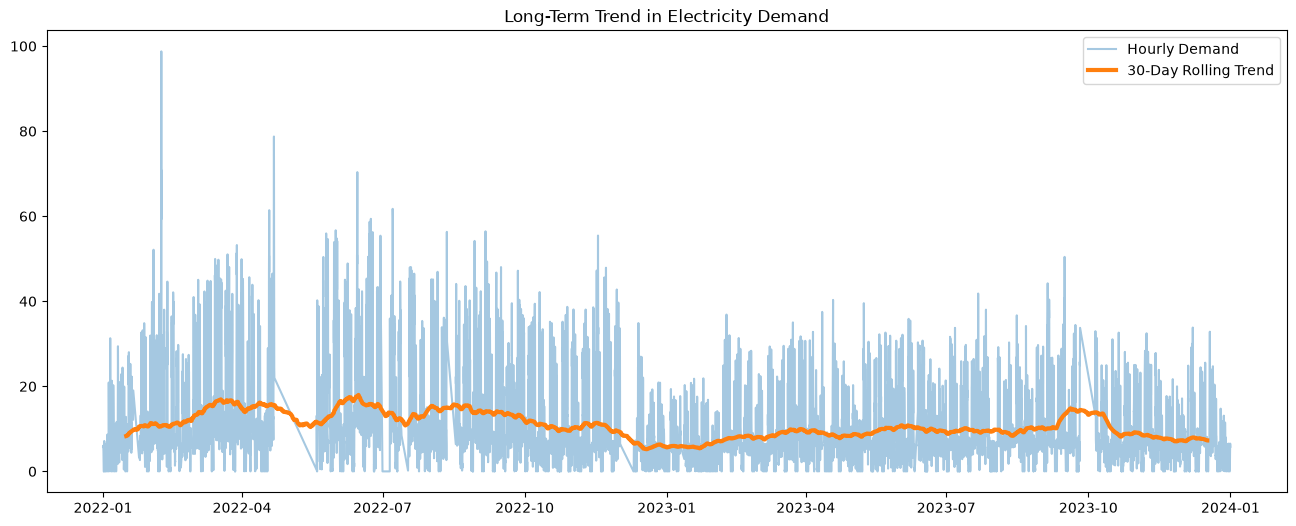

In [58]:
plt.figure(figsize=(16, 6))

plt.plot(
    df["demand_kWh"],
    alpha=0.4,
    label="Hourly Demand"
)

plt.plot(
    df["trend_30d"],
    linewidth=3,
    label="30-Day Rolling Trend"
)

plt.title("Long-Term Trend in Electricity Demand")
plt.legend()

plt.show()

Cycle Analysis

It is important to distinguish seasonality from cycles:

Seasonality → repeats at a known fixed frequency, such as every 24 hours or every 7 days.
Cyclic movement → longer-term rises and falls that do not necessarily repeat at a fixed interval.

For electricity demand, you can first visualize longer-term cycles using monthly aggregation and smoothing.

In [59]:
monthly_mean = df["demand_kWh"].resample("ME").mean()

monthly_trend = monthly_mean.rolling(
    window=3,
    center=True
).mean()

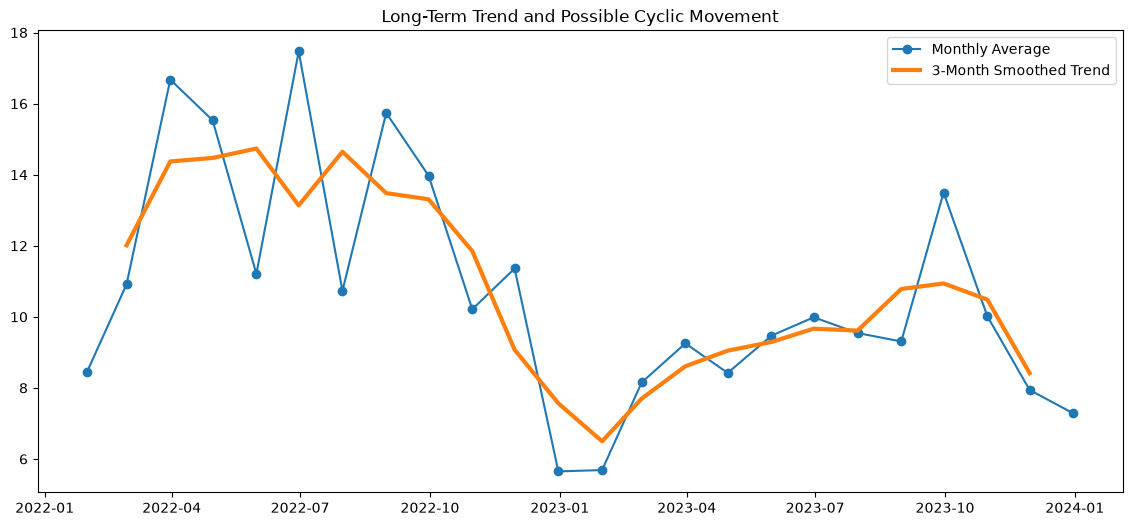

In [60]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_mean,
    marker="o",
    label="Monthly Average"
)

plt.plot(
    monthly_trend,
    linewidth=3,
    label="3-Month Smoothed Trend"
)

plt.title("Long-Term Trend and Possible Cyclic Movement")
plt.legend()

plt.show()

### Create a Train-Test Split

For forecasting, do not randomly split time-series data.

In [61]:
series = df["demand_kWh"].dropna()

train_size = int(len(series) * 0.80)

train = series.iloc[:train_size]
test = series.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 14015
Test size: 3504


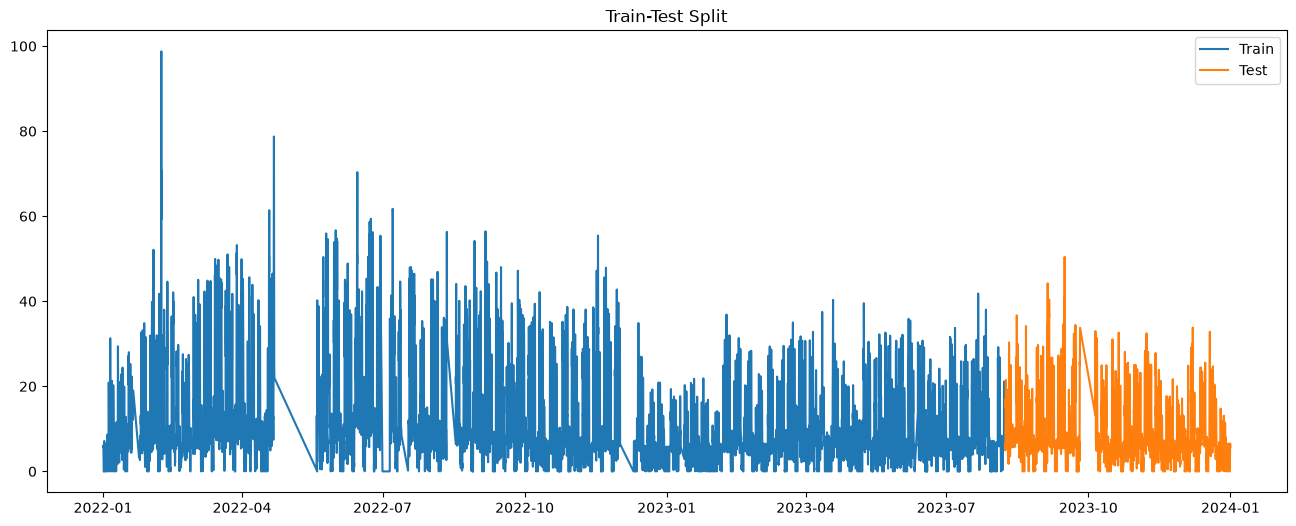

In [62]:
plt.figure(figsize=(16, 6))

plt.plot(
    train,
    label="Train"
)

plt.plot(
    test,
    label="Test"
)

plt.title("Train-Test Split")
plt.legend()

plt.show()

In [63]:
def evaluate_forecast(actual, predicted, model_name):

    mae = mean_absolute_error(actual, predicted)

    mse = mean_squared_error(actual, predicted)

    rmse = np.sqrt(mse)

    print(f"===== {model_name} =====")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    }

### AR Model

An AR(p) model can be represented through ARIMA with: ARIMA(p, 0, 0)

In [72]:
p = 25

ar_model = ARIMA(
    train,
    order=(p, 0, 0)
)

ar_results = ar_model.fit()

ar_forecast = ar_results.forecast(
    steps=len(test)
)

ar_metrics = evaluate_forecast(
    test,
    ar_forecast,
    f"AR({p})"
)

===== AR(25) =====
MAE  : 6.2758
MSE  : 59.1995
RMSE : 7.6941


===== AR(2) =====
MAE  : 6.3131
MSE  : 59.5193
RMSE : 7.7149

===== AR(25) =====
MAE  : 6.2758
MSE  : 59.1995
RMSE : 7.6941

===== AR(3) =====
MAE  : 6.3131
MSE  : 59.5194
RMSE : 7.7149

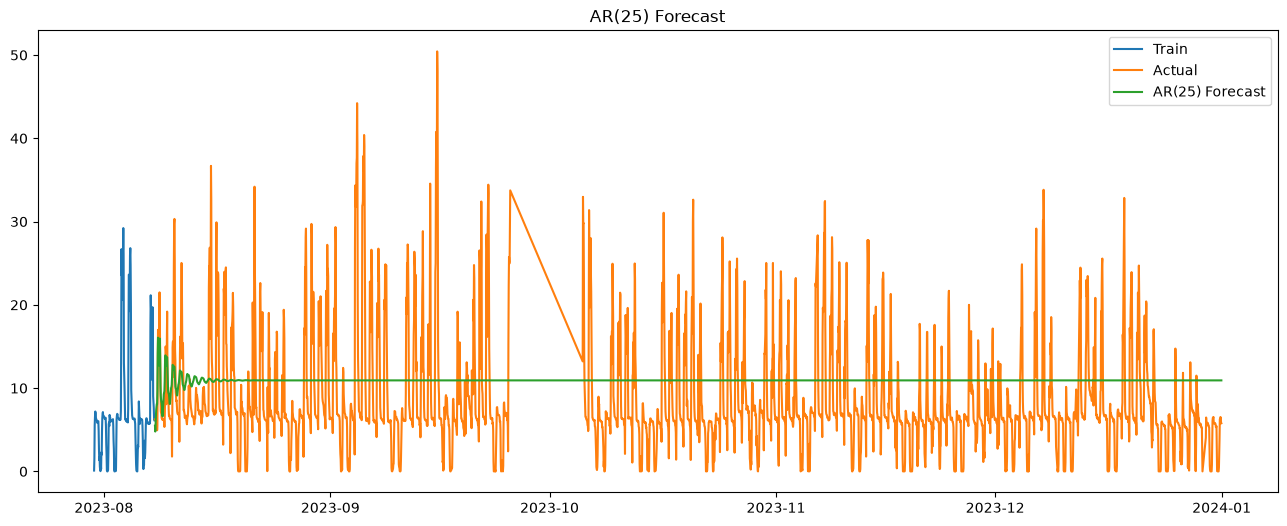

In [73]:
plt.figure(figsize=(16, 6))

plt.plot(
    train.tail(200),
    label="Train"
)

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    ar_forecast,
    label=f"AR({p}) Forecast"
)

plt.title(f"AR({p}) Forecast")

plt.legend()

plt.show()

### MA Model

An MA(q) model can be represented as: ARIMA(0, 0, q)

In [75]:
q = 4

ma_model = ARIMA(
    train,
    order=(0, 0, q)
)

ma_results = ma_model.fit()

ma_forecast = ma_results.forecast(
    steps=len(test)
)

ma_metrics = evaluate_forecast(
    test,
    ma_forecast,
    f"MA({q})"
)

===== MA(4) =====
MAE  : 6.3157
MSE  : 59.5358
RMSE : 7.7159


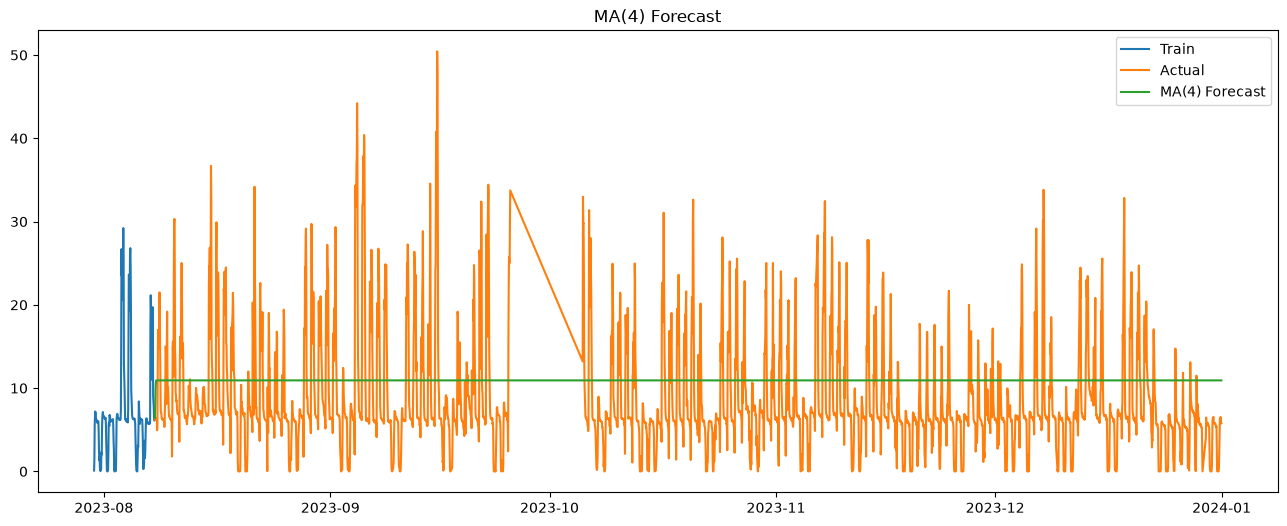

In [76]:
plt.figure(figsize=(16, 6))

plt.plot(
    train.tail(200),
    label="Train"
)

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    ma_forecast,
    label=f"MA({q}) Forecast"
)

plt.title(f"MA({q}) Forecast")

plt.legend()

plt.show()

### ARMA Model

An ARMA(p,q) model is: ARIMA(p, 0, q)

In [77]:
p = 25
q = 4

arma_model = ARIMA(
    train,
    order=(p, 0, q)
)

arma_results = arma_model.fit()

arma_forecast = arma_results.forecast(
    steps=len(test)
)

arma_metrics = evaluate_forecast(
    test,
    arma_forecast,
    f"ARMA({p},{q})"
)

===== ARMA(25,4) =====
MAE  : 6.2756
MSE  : 59.1985
RMSE : 7.6941


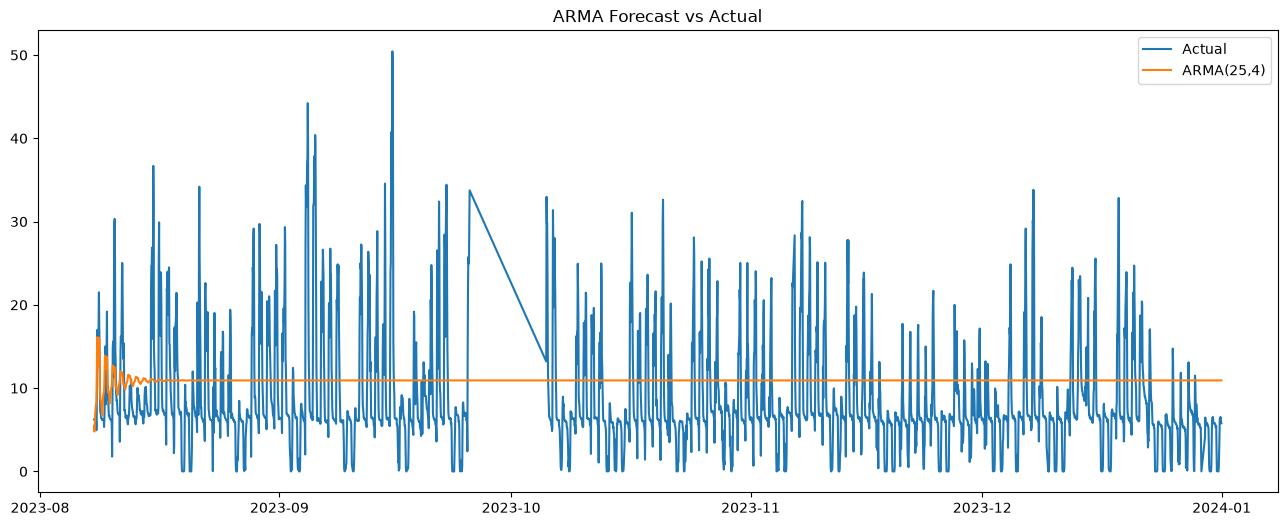

In [78]:
plt.figure(figsize=(16, 6))

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    arma_forecast,
    label=f"ARMA({p},{q})"
)

plt.title("ARMA Forecast vs Actual")

plt.legend()

plt.show()

Automatically Test Multiple AR Orders

Instead of manually guessing only one value of p, test several.

In [79]:
ar_results_list = []

for p in range(1, 11):

    try:

        model = ARIMA(
            train,
            order=(p, 0, 0)
        )

        result = model.fit()

        forecast = result.forecast(
            steps=len(test)
        )

        metrics = evaluate_forecast(
            test,
            forecast,
            f"AR({p})"
        )

        metrics["AIC"] = result.aic
        metrics["BIC"] = result.bic

        ar_results_list.append(metrics)

    except Exception as e:

        print(f"AR({p}) failed:", e)

===== AR(1) =====
MAE  : 6.3116
MSE  : 59.5225
RMSE : 7.7151
===== AR(2) =====
MAE  : 6.3131
MSE  : 59.5193
RMSE : 7.7149
===== AR(3) =====
MAE  : 6.3131
MSE  : 59.5194
RMSE : 7.7149
===== AR(4) =====
MAE  : 6.3131
MSE  : 59.5186
RMSE : 7.7148
===== AR(5) =====
MAE  : 6.3130
MSE  : 59.5169
RMSE : 7.7147
===== AR(6) =====
MAE  : 6.3126
MSE  : 59.5121
RMSE : 7.7144
===== AR(7) =====
MAE  : 6.3110
MSE  : 59.5016
RMSE : 7.7137
===== AR(8) =====
MAE  : 6.3100
MSE  : 59.4942
RMSE : 7.7133
===== AR(9) =====
MAE  : 6.3113
MSE  : 59.5041
RMSE : 7.7139
===== AR(10) =====
MAE  : 6.3123
MSE  : 59.5122
RMSE : 7.7144


In [80]:
# results
ar_comparison = pd.DataFrame(ar_results_list)

ar_comparison = ar_comparison.sort_values(
    "RMSE"
)

print(ar_comparison)

    Model       MAE        MSE      RMSE           AIC           BIC
7   AR(8)  6.309973  59.494243  7.713251  77673.227072  77748.705906
6   AR(7)  6.311002  59.501590  7.713727  77716.954243  77784.885194
8   AR(9)  6.311339  59.504097  7.713890  77558.768366  77641.795084
5   AR(6)  6.312580  59.512098  7.714408  77797.288995  77857.672062
9  AR(10)  6.312260  59.512168  7.714413  77462.028861  77552.603463
4   AR(5)  6.312989  59.516861  7.714717  77888.430740  77941.265924
3   AR(4)  6.313077  59.518598  7.714830  77920.594330  77965.881631
1   AR(2)  6.313128  59.519253  7.714872  77934.705103  77964.896637
2   AR(3)  6.313083  59.519388  7.714881  77933.426826  77971.166243
0   AR(1)  6.311623  59.522465  7.715080  78994.647829  79017.291479


Automatically Test Multiple MA Orders

An MA(q) model is represented as:

$$ MA(q) = ARIMA(0,0,q) $$

Test values of \(q\) from 1 to 10:

In [81]:
ma_results_list = []

for q in range(1, 11):

    try:
        model = ARIMA(
            train,
            order=(0, 0, q)
        )

        result = model.fit()

        forecast = result.forecast(
            steps=len(test)
        )

        metrics = evaluate_forecast(
            test,
            forecast,
            f"MA({q})"
        )

        metrics["AIC"] = result.aic
        metrics["BIC"] = result.bic

        ma_results_list.append(metrics)

    except Exception as e:
        print(f"MA({q}) failed:", e)

===== MA(1) =====
MAE  : 6.3176
MSE  : 59.5461
RMSE : 7.7166
===== MA(2) =====
MAE  : 6.3167
MSE  : 59.5406
RMSE : 7.7163
===== MA(3) =====
MAE  : 6.3170
MSE  : 59.5422
RMSE : 7.7164
===== MA(4) =====
MAE  : 6.3157
MSE  : 59.5358
RMSE : 7.7159
===== MA(5) =====
MAE  : 6.3151
MSE  : 59.5314
RMSE : 7.7157
===== MA(6) =====
MAE  : 6.3153
MSE  : 59.5311
RMSE : 7.7156
===== MA(7) =====
MAE  : 6.3155
MSE  : 59.5340
RMSE : 7.7158
===== MA(8) =====
MAE  : 6.3141
MSE  : 59.5272
RMSE : 7.7154
===== MA(9) =====
MAE  : 6.3126
MSE  : 59.5175
RMSE : 7.7148
===== MA(10) =====
MAE  : 6.3122
MSE  : 59.5154
RMSE : 7.7146


In [82]:
# create the comparision table
ma_comparison = pd.DataFrame(ma_results_list)

ma_comparison = ma_comparison.sort_values("RMSE")

print(ma_comparison)


    Model       MAE        MSE      RMSE           AIC           BIC
9  MA(10)  6.312175  59.515439  7.714625  77495.675815  77586.250416
8   MA(9)  6.312604  59.517540  7.714761  77540.432941  77623.459659
7   MA(8)  6.314112  59.527181  7.715386  77742.590254  77818.069088
5   MA(6)  6.315283  59.531073  7.715638  78835.966799  78896.349867
4   MA(5)  6.315108  59.531376  7.715658  78989.410792  79042.245977
6   MA(7)  6.315549  59.533978  7.715826  78329.815224  78397.746175
3   MA(4)  6.315691  59.535768  7.715942  79760.443672  79805.730973
1   MA(2)  6.316666  59.540643  7.716258  84024.833657  84055.025191
2   MA(3)  6.317005  59.542192  7.716359  81240.383952  81278.123369
0   MA(1)  6.317559  59.546129  7.716614  90237.476593  90260.120243


In [83]:
# Best MA model:
best_ma = ma_comparison.iloc[0]

print("Best MA Model:")
print(best_ma)

Best MA Model:
Model          MA(10)
MAE          6.312175
MSE         59.515439
RMSE         7.714625
AIC      77495.675815
BIC      77586.250416
Name: 9, dtype: object


Automatically Test ARMA Models

We can test combinations such as:

$$ ARMA(p,q) $$

where:

\(p\) = AR order
\(q\) = MA order

For example, test \(p=1\) to \(5\) and \(q=1\) to \(5\):

In [84]:
arma_results_list = []

for p in range(1, 6):

    for q in range(1, 6):

        try:

            print(f"Testing ARMA({p},{q})")

            model = ARIMA(
                train,
                order=(p, 0, q)
            )

            result = model.fit()

            forecast = result.forecast(
                steps=len(test)
            )

            metrics = evaluate_forecast(
                test,
                forecast,
                f"ARMA({p},{q})"
            )

            metrics["p"] = p
            metrics["q"] = q
            metrics["AIC"] = result.aic
            metrics["BIC"] = result.bic

            arma_results_list.append(metrics)

        except Exception as e:

            print(f"ARMA({p},{q}) failed:", e)

Testing ARMA(1,1)
===== ARMA(1,1) =====
MAE  : 6.3127
MSE  : 59.5197
RMSE : 7.7149
Testing ARMA(1,2)
===== ARMA(1,2) =====
MAE  : 6.3129
MSE  : 59.5193
RMSE : 7.7149
Testing ARMA(1,3)
===== ARMA(1,3) =====
MAE  : 6.3130
MSE  : 59.5191
RMSE : 7.7149
Testing ARMA(1,4)
===== ARMA(1,4) =====
MAE  : 6.3130
MSE  : 59.5188
RMSE : 7.7148
Testing ARMA(1,5)
===== ARMA(1,5) =====
MAE  : 6.3132
MSE  : 59.5188
RMSE : 7.7148
Testing ARMA(2,1)
===== ARMA(2,1) =====
MAE  : 6.3128
MSE  : 59.5181
RMSE : 7.7148
Testing ARMA(2,2)
===== ARMA(2,2) =====
MAE  : 6.3132
MSE  : 59.5221
RMSE : 7.7151
Testing ARMA(2,3)
===== ARMA(2,3) =====
MAE  : 6.3113
MSE  : 59.5098
RMSE : 7.7143
Testing ARMA(2,4)
===== ARMA(2,4) =====
MAE  : 6.3109
MSE  : 59.5011
RMSE : 7.7137
Testing ARMA(2,5)
===== ARMA(2,5) =====
MAE  : 6.3104
MSE  : 59.5002
RMSE : 7.7136
Testing ARMA(3,1)
===== ARMA(3,1) =====
MAE  : 6.3115
MSE  : 59.5103
RMSE : 7.7143
Testing ARMA(3,2)
===== ARMA(3,2) =====
MAE  : 6.3129
MSE  : 59.5182
RMSE : 7.7148
Test

In [85]:
#result table
arma_comparison = pd.DataFrame(arma_results_list)

arma_comparison = arma_comparison.sort_values("RMSE")

arma_comparison.head(10)

,Model,MAE,MSE,RMSE,p,q,AIC,BIC
20,"ARMA(5,1)",6.304837,59.468862,7.711606,5,1,77799.612265,77859.995333
24,"ARMA(5,5)",6.309655,59.470689,7.711724,5,5,77253.662850,77344.237452
22,"ARMA(5,3)",6.305815,59.479078,7.712268,5,3,77708.209729,77783.688564
18,"ARMA(4,4)",6.308441,59.480292,7.712347,4,4,77550.933656,77626.412490
13,"ARMA(3,4)",6.305415,59.480409,7.712354,3,4,77728.120843,77796.051794
16,"ARMA(4,2)",6.306705,59.486268,7.712734,4,2,77766.246760,77826.629828
21,"ARMA(5,2)",6.308344,59.495034,7.713302,5,2,77762.230416,77830.161367
17,"ARMA(4,3)",6.310006,59.498852,7.713550,4,3,77900.324470,77968.255421
9,"ARMA(2,5)",6.310443,59.500215,7.713638,2,5,77727.442169,77795.373121
8,"ARMA(2,4)",6.310879,59.501064,7.713693,2,4,77795.683279,77856.066347


In [86]:
#best arma model
best_arma = arma_comparison.iloc[0]

print("Best ARMA Model:")
print(best_arma)

Best ARMA Model:
Model       ARMA(5,1)
MAE          6.304837
MSE         59.468862
RMSE         7.711606
p                   5
q                   1
AIC      77799.612265
BIC      77859.995333
Name: 20, dtype: object


Compare the Best AR, MA and ARMA Models

First, get the best AR model:

In [87]:
#get the best AR model
best_ar = ar_comparison.iloc[0]

print("Best AR Model:")
print(best_ar)

Best AR Model:
Model           AR(8)
MAE          6.309973
MSE         59.494243
RMSE         7.713251
AIC      77673.227072
BIC      77748.705906
Name: 7, dtype: object


In [88]:
#get the best MA model
best_ma = ma_comparison.iloc[0]

print("\nBest MA Model:")
print(best_ma)


Best MA Model:
Model          MA(10)
MAE          6.312175
MSE         59.515439
RMSE         7.714625
AIC      77495.675815
BIC      77586.250416
Name: 9, dtype: object


In [89]:
# get the best arma model
best_arma = arma_comparison.iloc[0]

print("\nBest ARMA Model:")
print(best_arma)


Best ARMA Model:
Model       ARMA(5,1)
MAE          6.304837
MSE         59.468862
RMSE         7.711606
p                   5
q                   1
AIC      77799.612265
BIC      77859.995333
Name: 20, dtype: object


In [90]:
#combine them
best_models = pd.DataFrame([
    best_ar,
    best_ma,
    best_arma
])

best_models = best_models.sort_values("RMSE")

best_models

,Model,MAE,MSE,RMSE,AIC,BIC,p,q
20,"ARMA(5,1)",6.304837,59.468862,7.711606,77799.612265,77859.995333,5.0,1.0
7,AR(8),6.309973,59.494243,7.713251,77673.227072,77748.705906,NaN,NaN
9,MA(10),6.312175,59.515439,7.714625,77495.675815,77586.250416,NaN,NaN
